<a href="https://www.kaggle.com/code/younuskurakula/house-price-prediction?scriptVersionId=342530991" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Road Map for Doing Project

1. Business Understanding
    
2. Importing & Data Collection
       
3. Exploratory Data Analysis (EDA)
    
4. Data Cleaning ( Missing, Duplicates, Outliers, Spellings, Invalid, Text Cleaning(speacial cha), Fix column names, Remove uneccesary columns, Mixed Data,  

5. Train Validation Test Split
    
6.  Feature Extraction/Creation, Feature Encoding, Feature Scaling
    
7. Feature Selection ( Wrapper, Filter, Embedded)
    
8. Handle Imbalanced Data (Oversampling, Undersampling, Combination)
    
9. Model Building ( Supervised(ensemble))
    
10. Cross Validation 
    
11. Hyperparameter Optimization

12. Model Evaluation ( Regression, Reports)

# Step 1:- Business Understanding
    * We need to predict House Price
    * Based on the features like area, infrastructure, transport...etc 
    * Output submission file will like Submission.csv same format

# Step 2:- Importing & Data Collection

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


In [2]:
import pandas as pd

original_train_data = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')
original_test_data = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv')

sample_submission = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv')

# Using a copy data for safe side
train = original_train_data.copy()
test = original_test_data.copy()

# Diplay all columns
pd.set_option('display.max_columns', None)

# Step 3:- Exploratory Data Analysis (EDA) 
    Understand Data Structure, Target Analysis, Missing, Duplicates, Correlation with target, Num - Cat Columns,  Train Vs Test

In [3]:
train

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,953,953,GasA,Ex,Y,SBrkr,953,694,0,1647,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1999.0,RFn,2,460,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,Stone,119.0,TA,TA,CBlock,Gd,TA,No,ALQ,790,Rec,163,589,1542,GasA,TA,Y,SBrkr,2073,0,0,2073,1,0,2,0,3,1,TA,7,Min1,2,TA,Attchd,1978.0,Unf,2,500,TA,TA,Y,349,0,0,0,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,Ex,Gd,Stone,TA,Gd,No,GLQ,275,Unf,0,877,1152,GasA,Ex,Y,SBrkr,1188,1152,0,2340,0,0,2,0,4,1,Gd,9,Typ,2,Gd,Attchd,1941.0,RFn,1,252,TA,TA,Y,0,60,0,0,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1950,1996,Hip,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,TA,TA,Mn,GLQ,49,Rec,1029,0,1078,GasA,Gd,

In [4]:
test

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,20.0,TA,TA,PConc,TA,TA,No,GLQ,602.0,Unf,0.0,324.0,926.0,GasA,Ex,Y,SBrkr,926,678,0,1604,0.0,0.0,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,1998.0,Fin,2.0,470.0,TA,TA,Y,360,36,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,PConc,Gd,TA,No,ALQ,263.0,Unf,0.0,1017.0,1280.0,GasA,Ex,Y,SBrkr,1280,0,0,1280,0.0,0.0,2,0,2,1,Gd,5,Typ,0,NaN,Attchd,1992.0,RFn,2.0,506.0,TA,TA,Y,0,82,0,0,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,Twnhs,2Story,4,7,1970,1970,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Unf,0.0,Unf,0.0,546.0,546.0,GasA,Gd,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,5,Typ,0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal
1455,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,TwnhsE,2Story,4,5,1970,1970,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,252.0,Unf,0.0,294.0,546.0,GasA,TA,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,6,Typ,0,NaN,CarPort,1970.0,Unf,1.0,286.0,TA,TA,Y,0,24,0,0,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml
1456,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1Story,5,7,1960,1996,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,ALQ,1224.0,Unf,0.0,0.0,1224.0,GasA,Ex,Y,SBrkr,1224,0,0,1224,1.0,0.0,1,0,4,1,TA,7,Typ,1,TA,Detchd,1960.0,Unf,2.0,576.0,TA,TA,Y,474,0,0,0,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml
1457,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,SFoyer,5,5,1992,1992,Gable,CompShg,Hd

In [5]:
train.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1.5Fin,5,5,1993,1995,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,Wood,Gd,TA,No,GLQ,732,Unf,0,64,796,GasA,Ex,Y,SBrkr,796,566,0,1362,1,0,1,1,1,1,TA,5,Typ,0,NaN,Attchd,1993.0,Unf,2,480,TA,TA,Y,40,30,0,320,0,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm,1Fam,1Story,8,5,2004,2005,Gable,CompShg,VinylSd,VinylSd,Stone,186.0,Gd,TA,PConc,Ex,TA,Av,GLQ,1369,Unf,0,317,1686,GasA,Ex,Y,SBrkr,1694,0,0,1694,1,0,2,0,3,1,Gd,7,Typ,1,Gd,Attchd,2004.0,RFn,2,636,TA,TA,Y,255,57,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NWAmes,PosN,Norm,1Fam,2Story,7,6,1973,1973,Gable,CompShg,HdBoard,HdBoard,Stone,240.0,TA,TA,CBlock,Gd,TA,Mn,ALQ,859,BLQ,32,216,1107,GasA,Ex,Y,SBrkr,1107,983,0,2090,1,0,2,1,3,1,TA,7,Typ,2,TA,Attchd,1973.0,RFn,2,484,TA,TA,Y,235,204,228,0,0,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,OldTown,Artery,Norm,1Fam,1.5Fin,7,5,1931,1950,Gable,CompShg,BrkFace,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,TA,No,Unf,0,Unf,0,952,952,GasA,Gd,Y,FuseF,1022,752,0,1774,0,0,2,0,2,2,TA,8,Min1,2,TA,Detchd,1931.0,Unf,2,468,Fa,TA,Y,90,0,205,0,0,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,BrkSide,Artery,Artery,2fmCon,1.5Unf,5,6,1939,1950,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,BrkTil,TA,TA,No,GLQ,851,Unf,0,140,991,GasA,Ex,

In [6]:
train.tail(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1450,1451,90,RL,60.0,9000,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,NAmes,Norm,Norm,Duplex,2Story,5,5,1974,1974,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,Gd,TA,No,Unf,0,Unf,0,896,896,GasA,TA,Y,SBrkr,896,896,0,1792,0,0,2,2,4,2,TA,8,Typ,0,NaN,NaN,NaN,NaN,0,0,NaN,NaN,Y,32,45,0,0,0,0,NaN,NaN,NaN,0,9,2009,WD,Normal,136000
1451,1452,20,RL,78.0,9262,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm,1Fam,1Story,8,5,2008,2009,Gable,CompShg,CemntBd,CmentBd,Stone,194.0,Gd,TA,PConc,Gd,TA,No,Unf,0,Unf,0,1573,1573,GasA,Ex,Y,SBrkr,1578,0,0,1578,0,0,2,0,3,1,Ex,7,Typ,1,Gd,Attchd,2008.0,Fin,3,840,TA,TA,Y,0,36,0,0,0,0,NaN,NaN,NaN,0,5,2009,New,Partial,287090
1452,1453,180,RM,35.0,3675,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,TwnhsE,SLvl,5,5,2005,2005,Gable,CompShg,VinylSd,VinylSd,BrkFace,80.0,TA,TA,PConc,Gd,TA,Gd,GLQ,547,Unf,0,0,547,GasA,Gd,Y,SBrkr,1072,0,0,1072,1,0,1,0,2,1,TA,5,Typ,0,NaN,Basment,2005.0,Fin,2,525,TA,TA,Y,0,28,0,0,0,0,NaN,NaN,NaN,0,5,2006,WD,Normal,145000
1453,1454,20,RL,90.0,17217,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1Story,5,5,2006,2006,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,1140,1140,GasA,Ex,Y,SBrkr,1140,0,0,1140,0,0,1,0,3,1,TA,6,Typ,0,NaN,NaN,NaN,NaN,0,0,NaN,NaN,Y,36,56,0,0,0,0,NaN,NaN,NaN,0,7,2006,WD,Abnorml,84500
1454,1455,20,FV,62.0,7500,Pave,Pave,Reg,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm,1Fam,1Story,7,5,2004,2005,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,Gd,TA,PConc,Gd,TA,No,GLQ,410,Unf,0,811,1221,GasA,Ex,Y,SBrkr,1221,0,0,1221,1,0,2,0,2,1,Gd,6,Typ,0,NaN,Attchd,2004.0,RFn,2,400,TA,TA,Y,0,113,0,0,0,0,NaN,NaN,NaN,0,10,2009,WD,Normal,185000
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,953,953,GasA,Ex,Y,SBrkr,953,694,0,1647,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1999.0,RFn,2,460,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,Stone,119.0,TA,TA,CBlock,Gd,TA,No,ALQ,790,Rec,163,589,1542,GasA,TA,Y,SBrkr,2073,0,0,2073,1,0,2,0,3,1,TA,7,Min1,2,TA,Attchd,1978.0,Unf,2,500,TA,TA,Y,349,0,0,0,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,Ex,Gd,Stone,TA,Gd,No,GLQ,275,Unf,0,877,1152,GasA,Ex,Y,SBrkr,1188,1152,0,2340,0,0,2,0,4,1,Gd,9,Typ,2,Gd,Attchd,1941.0,RFn,1,252,TA,TA,Y,0,60,0,0,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1950,1996,Hip,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,TA,TA,Mn,GLQ,49,Rec,1029,0,1078,GasA,Gd,Y,FuseA,1078,0,0,1078,1,0,1,0,2,1,Gd,5,Typ,0,NaN,Attchd,1950.0,Unf,1,240,TA,TA,Y,366,0,112,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,1Fam,1Story,5,6,1965,1965,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,CBlock,TA,TA,No,BLQ,830,LwQ,290,136,1256

In [7]:
train.sample(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
128,129,60,RL,69.0,7590,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,PosN,Norm,1Fam,2Story,6,5,1966,1966,Gable,CompShg,VinylSd,VinylSd,BrkFace,266.0,TA,TA,CBlock,TA,TA,No,BLQ,512,Unf,0,148,660,GasA,TA,Y,SBrkr,660,688,0,1348,0,0,1,1,3,1,TA,6,Typ,1,Fa,Attchd,1966.0,RFn,2,453,TA,TA,Y,188,108,0,0,0,0,NaN,NaN,NaN,0,7,2006,WD,Normal,155000
1115,1116,20,RL,93.0,12085,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NridgHt,Norm,Norm,1Fam,1Story,8,5,2007,2007,Hip,CompShg,VinylSd,VinylSd,Stone,328.0,Gd,TA,PConc,Ex,TA,No,GLQ,1004,Unf,0,730,1734,GasA,Ex,Y,SBrkr,1734,0,0,1734,1,0,2,0,3,1,Ex,7,Typ,1,Gd,Attchd,2007.0,RFn,3,928,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,11,2007,New,Partial,318000
404,405,60,RL,NaN,10364,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1995,1996,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,806,806,GasA,Gd,Y,SBrkr,806,766,0,1572,0,0,2,1,3,1,TA,7,Typ,1,TA,BuiltIn,1995.0,Fin,2,373,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,168000
566,567,60,RL,77.0,11198,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,StoneBr,Norm,Norm,1Fam,2Story,9,5,2005,2007,Hip,CompShg,VinylSd,VinylSd,BrkFace,245.0,Gd,TA,PConc,Gd,Gd,No,Unf,0,Unf,0,1122,1122,GasA,Ex,Y,SBrkr,1134,1370,0,2504,0,0,2,1,4,1,Ex,11,Typ,1,Gd,BuiltIn,2005.0,Fin,3,656,TA,TA,Y,144,39,0,0,0,0,NaN,NaN,NaN,0,6,2008,WD,Normal,325000
260,261,80,RL,120.0,19296,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Artery,Norm,1Fam,SLvl,6,5,1962,1962,Gable,CompShg,Wd Sdng,Wd Sdng,BrkFace,399.0,TA,TA,CBlock,TA,TA,Gd,Rec,672,ALQ,690,0,1362,GasA,TA,Y,SBrkr,1382,0,0,1382,1,0,1,0,3,1,TA,6,Typ,1,TA,Attchd,1991.0,Unf,2,884,TA,TA,Y,0,0,252,0,0,0,NaN,GdWo,NaN,0,5,2009,WD,Normal,176000
323,324,20,RM,49.0,5820,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,OldTown,Norm,Norm,1Fam,1Story,3,8,1955,2005,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,Gd,CBlock,TA,TA,No,ALQ,256,Unf,0,906,1162,GasA,Ex,Y,SBrkr,1163,0,0,1163,1,0,1,0,3,1,TA,6,Typ,0,NaN,Attchd,1955.0,Unf,1,220,Fa,TA,Y,142,98,0,0,0,0,NaN,NaN,NaN,0,7,2006,WD,Normal,126175
1386,1387,60,RL,80.0,16692,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,NWAmes,RRAn,Norm,1Fam,2Story,7,5,1978,1978,Gable,CompShg,Plywood,Plywood,BrkFace,184.0,TA,TA,CBlock,Gd,TA,No,BLQ,790,LwQ,469,133,1392,GasA,TA,Y,SBrkr,1392,1392,0,2784,1,0,3,1,5,1,Gd,12,Typ,2,TA,Attchd,1978.0,RFn,2,564,TA,TA,Y,0,112,0,0,440,519,Fa,MnPrv,TenC,2000,7,2006,WD,Normal,250000
586,587,30,RL,55.0,10267,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,BrkSide,RRAn,Norm,1Fam,1Story,6,7,1918,2000,Gable,CompShg,Stucco,Wd Shng,NaN,0.0,TA,Gd,BrkTil,TA,Gd,Mn,Rec,210,ALQ,606,0,816,GasA,Ex,Y,SBrkr,838,0,0,838,1,0,1,0,2,1,Fa,5,Typ,0,NaN,Detchd,1961.0,Fin,1,275,TA,TA,N,0,0,112,0,0,0,NaN,MnWw,NaN,0,5,2008,WD,Normal,130000
382,383,60,RL,79.0,9245,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2006,2006,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,Gd,TA,PConc,Gd,TA,Av,Unf,0,Unf,0,939,939,GasA,Ex,Y,SBrkr,939,858,0,1797,0,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2006.0,RFn,2,639,TA,TA,Y,144,53,0,0,0,0,NaN,NaN,NaN,0,4,2007,WD,Normal,213500
1030,1031,190,RH,NaN,7082,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,SWISU,Norm,Norm,2fmCon,2Story,5,8,1916,1995,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,TA,TA,M

In [8]:
train.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [9]:
train.columns.to_list()

['Id',
 'MSSubClass',
 'MSZoning',
 'LotFrontage',
 'LotArea',
 'Street',
 'Alley',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'MasVnrArea',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinSF1',
 'BsmtFinType2',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'KitchenQual',
 'TotRmsAbvGrd',
 'Functional',
 'Fireplaces',
 'FireplaceQu',
 'GarageType',
 'GarageYrBlt',
 'GarageFinish',
 'GarageCars',
 'GarageArea',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'WoodDeckSF',
 'OpenPorchSF'

In [10]:
train.index

RangeIndex(start=0, stop=1460, step=1)

In [11]:
train.dtypes

Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 81, dtype: object

In [12]:
train.dtypes.value_counts()

object     43
int64      35
float64     3
Name: count, dtype: int64

In [13]:
train.value_counts()

Series([], Name: count, dtype: int64)

In [14]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [15]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


# Saleprice 
    Minimum - 34,900 
    25%     - 1,29,975
    Middle  - 1,63,000
    75 %    - 2,14,000
    Maximum - 7,55,000

 So almost Sale Prices will be 1,00,000 - 2,14,000 Lakhs
 It is Right Skewed becuase intially Prices are small suddenly in the end prices increased huge so Right Skewed

In [16]:
train['Id'].is_unique

True

In [17]:
test['Id'].is_unique

True

# Target Analysis

In [18]:
train['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [19]:
train['SalePrice'].skew()

np.float64(1.8828757597682129)

In [20]:
train['SalePrice'].kurtosis()

np.float64(6.536281860064529)

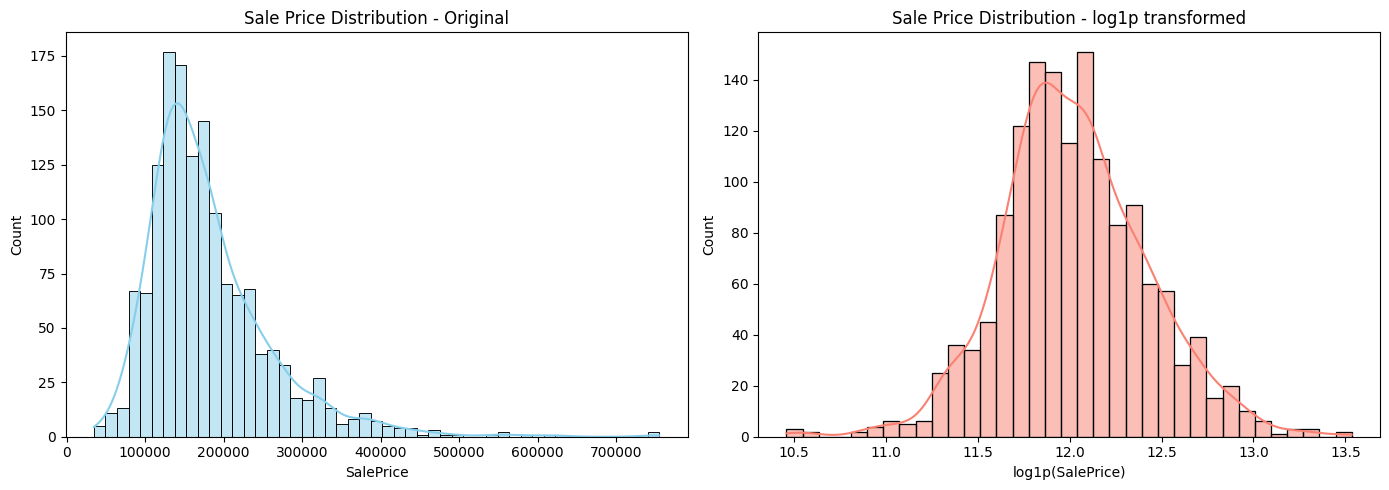

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution Plot

fig, axes = plt.subplots(1, 2, figsize = (14, 5))

sns.histplot(train['SalePrice'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Sale Price Distribution - Original')
axes[0].set_xlabel('SalePrice')

sns.histplot(np.log1p(train['SalePrice']), kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Sale Price Distribution - log1p transformed')
axes[1].set_xlabel('log1p(SalePrice)')

plt.tight_layout()
plt.show()


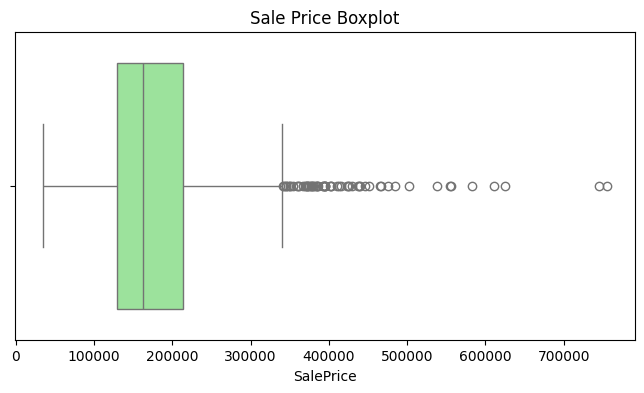

In [22]:
# Boxplot 

plt.figure(figsize=(8,4))
sns.boxplot(x=train['SalePrice'], color='lightgreen')
plt.title('Sale Price Boxplot')
plt.show()

# Check Duplicates for Train, Test and Ids

In [23]:
print(train.duplicated().sum())
print(train['Id'].duplicated().sum())

print(test.duplicated().sum())
print(test['Id'].duplicated().sum())

0
0
0
0


No Duplicates in Train and Test Datasets

# Numerical Features

In [24]:
# Select numerical columns (exclude Id and SalePrice)
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [col for col in num_cols if col not in ['Id', 'SalePrice']]

print(f"Number of numerical features: {len(num_cols)}")

# Skewness
skewness = train[num_cols].skew().sort_values(ascending=False)
print("\n=== Top 10 Most Skewed Features ===")
print(skewness.head(10))

# Correlation with target
corr_with_target = train[num_cols + ['SalePrice']].corr()['SalePrice'].sort_values(ascending=False)
print("\n=== Top 15 Features Correlated with SalePrice ===")
print(corr_with_target.head(16))

Number of numerical features: 36

=== Top 10 Most Skewed Features ===
MiscVal          24.476794
PoolArea         14.828374
LotArea          12.207688
3SsnPorch        10.304342
LowQualFinSF      9.011341
KitchenAbvGr      4.488397
BsmtFinSF2        4.255261
ScreenPorch       4.122214
BsmtHalfBath      4.103403
EnclosedPorch     3.089872
dtype: float64

=== Top 15 Features Correlated with SalePrice ===
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.351799
Name: SalePrice, dtype: float64


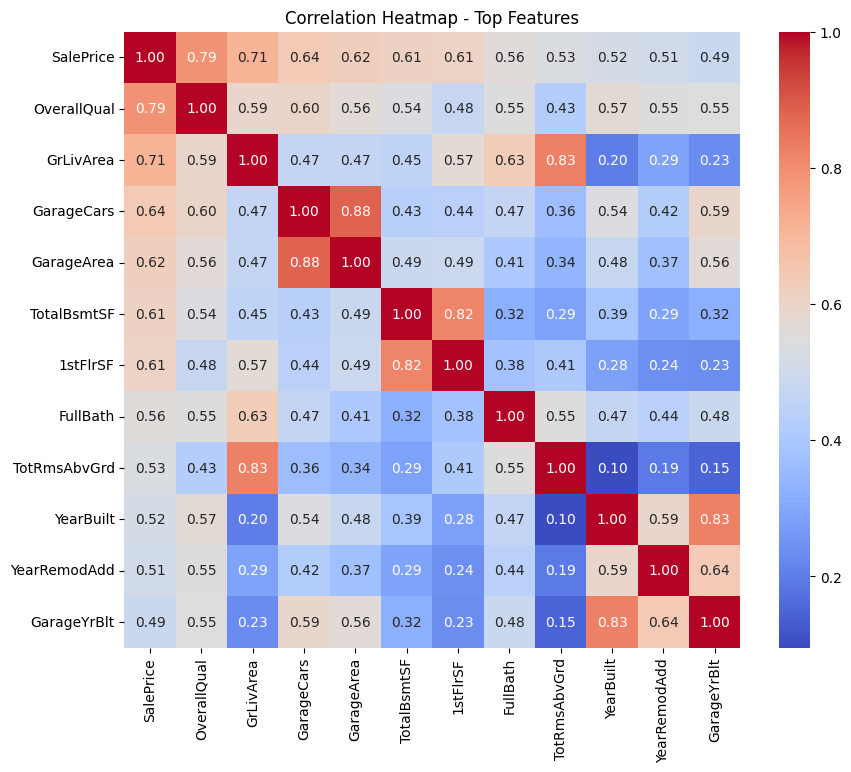

In [25]:
# Correlation Heatmap (Top features only)

top_corr_features = corr_with_target.head(12).index.tolist()

plt.figure(figsize=(10, 8))
sns.heatmap(train[top_corr_features].corr(), annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Heatmap - Top Features')
plt.show()

# Categorical Features

Number of categorical features: 43

=== Cardinality (Unique Values) ===
Neighborhood     25
Exterior2nd      16
Exterior1st      15
Condition1        9
SaleType          9
HouseStyle        8
RoofMatl          8
Condition2        8
Functional        7
BsmtFinType2      6
RoofStyle         6
BsmtFinType1      6
SaleCondition     6
Heating           6
Foundation        6
GarageType        6
ExterCond         5
LotConfig         5
MSZoning          5
GarageCond        5
GarageQual        5
HeatingQC         5
Electrical        5
BldgType          5
FireplaceQu       5
LandContour       4
LotShape          4
KitchenQual       4
MiscFeature       4
Fence             4
BsmtCond          4
ExterQual         4
BsmtExposure      4
BsmtQual          4
LandSlope         3
PoolQC            3
GarageFinish      3
PavedDrive        3
MasVnrType        3
Utilities         2
Alley             2
Street            2
CentralAir        2
dtype: int64


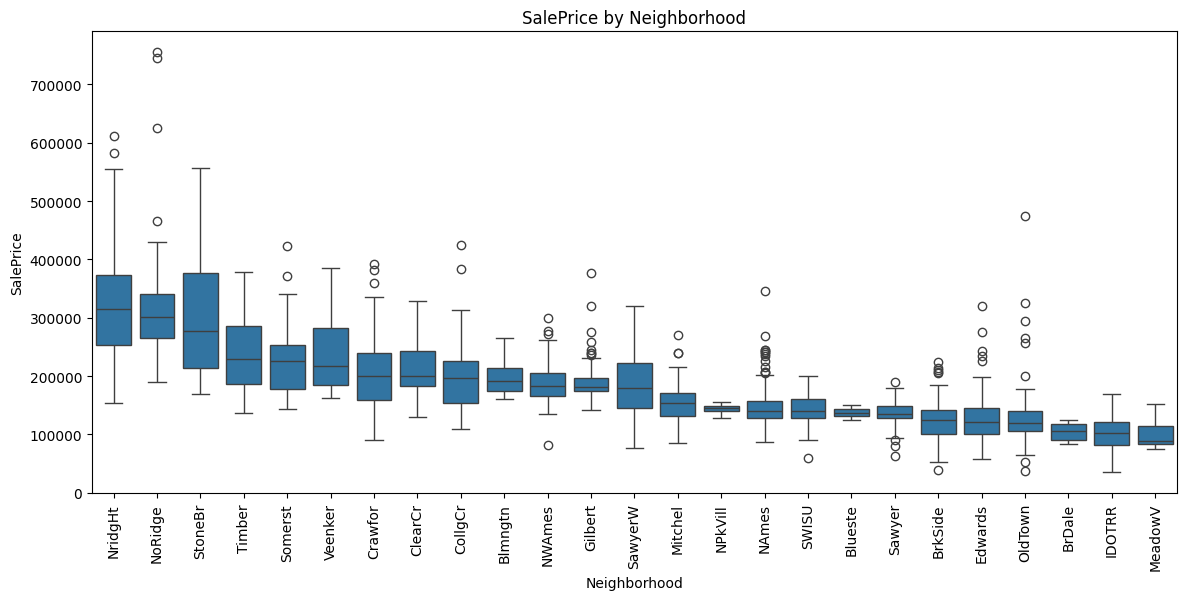

/tmp/ipykernel_16/4277197024.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='OverallQual', y='SalePrice', data=train, palette='Blues')


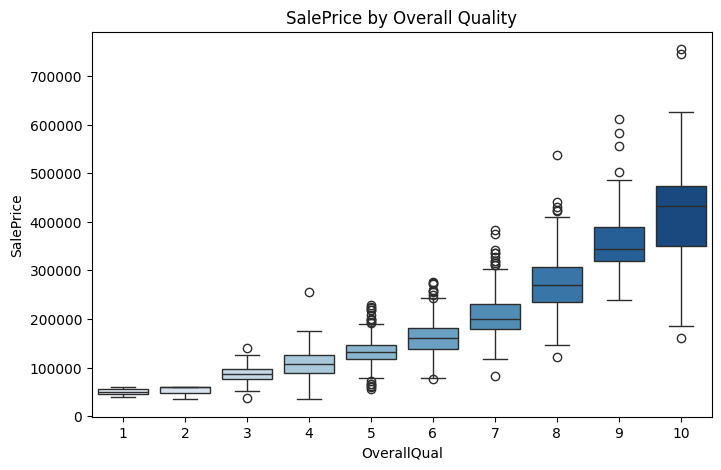

In [26]:
cat_cols = train.select_dtypes(include=['object']).columns.tolist()
print(f"Number of categorical features: {len(cat_cols)}")

# Cardinality
cardinality = train[cat_cols].nunique().sort_values(ascending=False)
print("\n=== Cardinality (Unique Values) ===")
print(cardinality)

# Example: Neighborhood vs SalePrice
plt.figure(figsize=(14, 6))
order = train.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False).index
sns.boxplot(x='Neighborhood', y='SalePrice', data=train, order=order)
plt.xticks(rotation=90)
plt.title('SalePrice by Neighborhood')
plt.show()

# OverallQual (very strong feature)
plt.figure(figsize=(8, 5))
sns.boxplot(x='OverallQual', y='SalePrice', data=train, palette='Blues')
plt.title('SalePrice by Overall Quality')
plt.show()

# Important Relationships

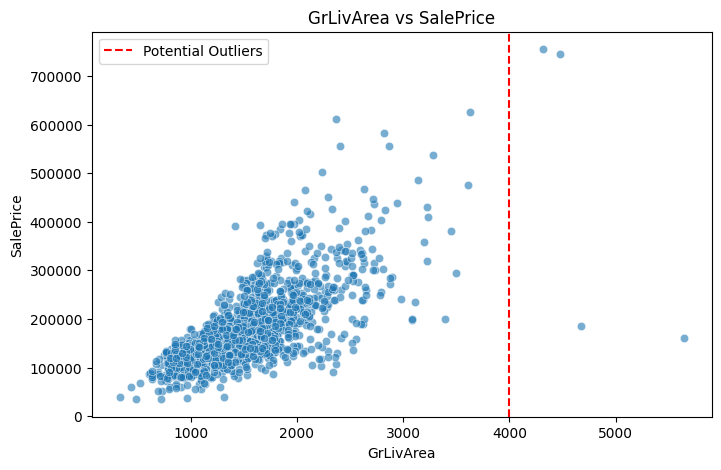

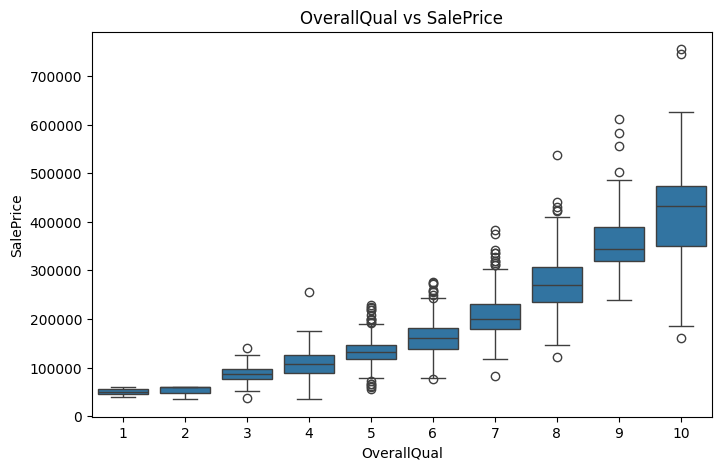

In [27]:
# GrLivArea vs SalePrice (shows outliers clearly)
plt.figure(figsize=(8, 5))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=train, alpha=0.6)
plt.title('GrLivArea vs SalePrice')
plt.axvline(x=4000, color='red', linestyle='--', label='Potential Outliers')
plt.legend()
plt.show()

# OverallQual vs SalePrice
plt.figure(figsize=(8, 5))
sns.boxplot(x='OverallQual', y='SalePrice', data=train)
plt.title('OverallQual vs SalePrice')
plt.show()

# Train vs Test Comparison

In [28]:
# Check categories that appear only in test
print("=== Categories present only in Test set ===")
for col in cat_cols:
    train_unique = set(train[col].dropna().unique())
    test_unique  = set(test[col].dropna().unique())
    only_in_test = test_unique - train_unique
    if only_in_test:
        print(f"{col}: {only_in_test}")

=== Categories present only in Test set ===


# Outliers

In [29]:
# Houses with very large living area
outliers = train[train['GrLivArea'] > 4000][['Id', 'GrLivArea', 'SalePrice', 'OverallQual']]
print("=== Potential Outliers (GrLivArea > 4000) ===")
display(outliers)

=== Potential Outliers (GrLivArea > 4000) ===


,Id,GrLivArea,SalePrice,OverallQual
523,524,4676,184750,10
691,692,4316,755000,10
1182,1183,4476,745000,10
1298,1299,5642,160000,10


# Step 4:- Data Cleaning ( Missing, Duplicates, Outliers, Spellings, Invalid, Text Cleaning(speacial cha), Fix column names, Remove uneccesary columns, Mixed Data, 

In [30]:
print("Before cleaning:")
print(f"Train: {train.shape} | Test: {test.shape}")

Before cleaning:
Train: (1460, 81) | Test: (1459, 80)


In [31]:
train

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,953,953,GasA,Ex,Y,SBrkr,953,694,0,1647,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1999.0,RFn,2,460,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,Stone,119.0,TA,TA,CBlock,Gd,TA,No,ALQ,790,Rec,163,589,1542,GasA,TA,Y,SBrkr,2073,0,0,2073,1,0,2,0,3,1,TA,7,Min1,2,TA,Attchd,1978.0,Unf,2,500,TA,TA,Y,349,0,0,0,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,Ex,Gd,Stone,TA,Gd,No,GLQ,275,Unf,0,877,1152,GasA,Ex,Y,SBrkr,1188,1152,0,2340,0,0,2,0,4,1,Gd,9,Typ,2,Gd,Attchd,1941.0,RFn,1,252,TA,TA,Y,0,60,0,0,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1950,1996,Hip,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,TA,TA,Mn,GLQ,49,Rec,1029,0,1078,GasA,Gd,

In [32]:
# 1. Remove clear outliers from TRAIN only
# These two houses have huge living area but unusually low price

outliers = train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)].index
print(f"\nRemoving {len(outliers)} outliers from train...")
train = train.drop(outliers)

train


Removing 2 outliers from train...


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,953,953,GasA,Ex,Y,SBrkr,953,694,0,1647,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1999.0,RFn,2,460,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,Stone,119.0,TA,TA,CBlock,Gd,TA,No,ALQ,790,Rec,163,589,1542,GasA,TA,Y,SBrkr,2073,0,0,2073,1,0,2,0,3,1,TA,7,Min1,2,TA,Attchd,1978.0,Unf,2,500,TA,TA,Y,349,0,0,0,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,Ex,Gd,Stone,TA,Gd,No,GLQ,275,Unf,0,877,1152,GasA,Ex,Y,SBrkr,1188,1152,0,2340,0,0,2,0,4,1,Gd,9,Typ,2,Gd,Attchd,1941.0,RFn,1,252,TA,TA,Y,0,60,0,0,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1950,1996,Hip,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,TA,TA,Mn,GLQ,49,Rec,1029,0,1078,GasA,Gd,

In [33]:
# 2. Combine train + test for consistent cleaning
#    (We will split them back later)

train['is_train'] = 1
test['is_train']  = 0
test['SalePrice'] = np.nan          # temporary

all_data = pd.concat([train, test], axis=0).reset_index(drop=True)
print(f"Combined shape: {all_data.shape}")
all_data

Combined shape: (2917, 82)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,is_train
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706.0,Unf,0.0,150.0,856.0,GasA,Ex,Y,SBrkr,856,854,0,1710,1.0,0.0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2.0,548.0,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.0,1
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.0,Unf,0.0,284.0,1262.0,GasA,Ex,Y,SBrkr,1262,0,0,1262,0.0,1.0,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2.0,460.0,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0,1
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486.0,Unf,0.0,434.0,920.0,GasA,Ex,Y,SBrkr,920,866,0,1786,1.0,0.0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2.0,608.0,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500.0,1
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216.0,Unf,0.0,540.0,756.0,GasA,Gd,Y,SBrkr,961,756,0,1717,1.0,0.0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3.0,642.0,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0,1
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655.0,Unf,0.0,490.0,1145.0,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1.0,0.0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3.0,836.0,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2912,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,Twnhs,2Story,4,7,1970,1970,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Unf,0.0,Unf,0.0,546.0,546.0,GasA,Gd,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,5,Typ,0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal,NaN,0
2913,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,TwnhsE,2Story,4,5,1970,1970,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,252.0,Unf,0.0,294.0,546.0,GasA,TA,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,6,Typ,0,NaN,CarPort,1970.0,Unf,1.0,286.0,TA,TA,Y,0,24,0,0,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml,NaN,0
2914,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1Story,5,7,1960,1996,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,ALQ,1224.0,Unf,0.0,0.0,1224.0,GasA,Ex,Y,SBrkr,1224,0,0,1224,1.0,0.0,1,0,4,1,TA,7,Typ,1,TA,Detchd,1960.0,Unf,2.0,576.0,TA,TA,Y,474,0,0,0,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml,NaN,0
2915,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,Al

In [34]:
# 3. Handle Missing Values
# 3.1 Features where NA means "None" / does not exist

none_cols = [
    'Alley', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'PoolQC', 'Fence', 'MiscFeature', 'MasVnrType'
]

for col in none_cols:
    all_data[col] = all_data[col].fillna('None')
all_data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,is_train
0,1,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706.0,Unf,0.0,150.0,856.0,GasA,Ex,Y,SBrkr,856,854,0,1710,1.0,0.0,2,1,3,1,Gd,8,Typ,0,None,Attchd,2003.0,RFn,2.0,548.0,TA,TA,Y,0,61,0,0,0,0,None,None,None,0,2,2008,WD,Normal,208500.0,1
1,2,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.0,Unf,0.0,284.0,1262.0,GasA,Ex,Y,SBrkr,1262,0,0,1262,0.0,1.0,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2.0,460.0,TA,TA,Y,298,0,0,0,0,0,None,None,None,0,5,2007,WD,Normal,181500.0,1
2,3,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486.0,Unf,0.0,434.0,920.0,GasA,Ex,Y,SBrkr,920,866,0,1786,1.0,0.0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2.0,608.0,TA,TA,Y,0,42,0,0,0,0,None,None,None,0,9,2008,WD,Normal,223500.0,1
3,4,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216.0,Unf,0.0,540.0,756.0,GasA,Gd,Y,SBrkr,961,756,0,1717,1.0,0.0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3.0,642.0,TA,TA,Y,0,35,272,0,0,0,None,None,None,0,2,2006,WD,Abnorml,140000.0,1
4,5,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655.0,Unf,0.0,490.0,1145.0,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1.0,0.0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3.0,836.0,TA,TA,Y,192,84,0,0,0,0,None,None,None,0,12,2008,WD,Normal,250000.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2912,2915,160,RM,21.0,1936,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,Twnhs,2Story,4,7,1970,1970,Gable,CompShg,CemntBd,CmentBd,None,0.0,TA,TA,CBlock,TA,TA,No,Unf,0.0,Unf,0.0,546.0,546.0,GasA,Gd,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,5,Typ,0,None,None,NaN,None,0.0,0.0,None,None,Y,0,0,0,0,0,0,None,None,None,0,6,2006,WD,Normal,NaN,0
2913,2916,160,RM,21.0,1894,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,TwnhsE,2Story,4,5,1970,1970,Gable,CompShg,CemntBd,CmentBd,None,0.0,TA,TA,CBlock,TA,TA,No,Rec,252.0,Unf,0.0,294.0,546.0,GasA,TA,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,6,Typ,0,None,CarPort,1970.0,Unf,1.0,286.0,TA,TA,Y,0,24,0,0,0,0,None,None,None,0,4,2006,WD,Abnorml,NaN,0
2914,2917,20,RL,160.0,20000,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1Story,5,7,1960,1996,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,CBlock,TA,TA,No,ALQ,1224.0,Unf,0.0,0.0,1224.0,GasA,Ex,Y,SBrkr,1224,0,0,1224,1.0,0.0,1,0,4,1,TA,7,Typ,1,TA,Detchd,1960.0,Unf,2.0,576.0,TA,TA,Y,474,0,0,0,0,0,None,None,None,0,9,2006,WD,Abnorml,NaN,0
29

In [35]:
# 3.2 Numerical features related to the above → fill with 0

zero_cols = [
    'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    'BsmtFullBath', 'BsmtHalfBath', 'GarageYrBlt', 'GarageCars', 'GarageArea'
]

for col in zero_cols:
    all_data[col] = all_data[col].fillna(0) 
all_data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,is_train
0,1,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706.0,Unf,0.0,150.0,856.0,GasA,Ex,Y,SBrkr,856,854,0,1710,1.0,0.0,2,1,3,1,Gd,8,Typ,0,None,Attchd,2003.0,RFn,2.0,548.0,TA,TA,Y,0,61,0,0,0,0,None,None,None,0,2,2008,WD,Normal,208500.0,1
1,2,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.0,Unf,0.0,284.0,1262.0,GasA,Ex,Y,SBrkr,1262,0,0,1262,0.0,1.0,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2.0,460.0,TA,TA,Y,298,0,0,0,0,0,None,None,None,0,5,2007,WD,Normal,181500.0,1
2,3,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486.0,Unf,0.0,434.0,920.0,GasA,Ex,Y,SBrkr,920,866,0,1786,1.0,0.0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2.0,608.0,TA,TA,Y,0,42,0,0,0,0,None,None,None,0,9,2008,WD,Normal,223500.0,1
3,4,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216.0,Unf,0.0,540.0,756.0,GasA,Gd,Y,SBrkr,961,756,0,1717,1.0,0.0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3.0,642.0,TA,TA,Y,0,35,272,0,0,0,None,None,None,0,2,2006,WD,Abnorml,140000.0,1
4,5,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655.0,Unf,0.0,490.0,1145.0,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1.0,0.0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3.0,836.0,TA,TA,Y,192,84,0,0,0,0,None,None,None,0,12,2008,WD,Normal,250000.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2912,2915,160,RM,21.0,1936,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,Twnhs,2Story,4,7,1970,1970,Gable,CompShg,CemntBd,CmentBd,None,0.0,TA,TA,CBlock,TA,TA,No,Unf,0.0,Unf,0.0,546.0,546.0,GasA,Gd,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,5,Typ,0,None,None,0.0,None,0.0,0.0,None,None,Y,0,0,0,0,0,0,None,None,None,0,6,2006,WD,Normal,NaN,0
2913,2916,160,RM,21.0,1894,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,TwnhsE,2Story,4,5,1970,1970,Gable,CompShg,CemntBd,CmentBd,None,0.0,TA,TA,CBlock,TA,TA,No,Rec,252.0,Unf,0.0,294.0,546.0,GasA,TA,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,6,Typ,0,None,CarPort,1970.0,Unf,1.0,286.0,TA,TA,Y,0,24,0,0,0,0,None,None,None,0,4,2006,WD,Abnorml,NaN,0
2914,2917,20,RL,160.0,20000,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1Story,5,7,1960,1996,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,CBlock,TA,TA,No,ALQ,1224.0,Unf,0.0,0.0,1224.0,GasA,Ex,Y,SBrkr,1224,0,0,1224,1.0,0.0,1,0,4,1,TA,7,Typ,1,TA,Detchd,1960.0,Unf,2.0,576.0,TA,TA,Y,474,0,0,0,0,0,None,None,None,0,9,2006,WD,Abnorml,NaN,0
29

In [36]:
all_data['LotFrontage'].isna().sum()

np.int64(486)

In [37]:
# 3.3 LotFrontage → median by Neighborhood

all_data['LotFrontage'] = all_data.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)
all_data['LotFrontage'].isna().sum()

np.int64(0)

In [38]:
# 3.4 Remaining missing values - very few

all_data['Electrical']   = all_data['Electrical'].fillna(all_data['Electrical'].mode()[0])
all_data['MSZoning']     = all_data['MSZoning'].fillna(all_data['MSZoning'].mode()[0])
all_data['Utilities']    = all_data['Utilities'].fillna('AllPub')
all_data['Functional']   = all_data['Functional'].fillna('Typ')
all_data['SaleType']     = all_data['SaleType'].fillna(all_data['SaleType'].mode()[0])
all_data['KitchenQual']  = all_data['KitchenQual'].fillna(all_data['KitchenQual'].mode()[0])
all_data['Exterior1st']  = all_data['Exterior1st'].fillna(all_data['Exterior1st'].mode()[0])
all_data['Exterior2nd']  = all_data['Exterior2nd'].fillna(all_data['Exterior2nd'].mode()[0])
all_data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,is_train
0,1,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706.0,Unf,0.0,150.0,856.0,GasA,Ex,Y,SBrkr,856,854,0,1710,1.0,0.0,2,1,3,1,Gd,8,Typ,0,None,Attchd,2003.0,RFn,2.0,548.0,TA,TA,Y,0,61,0,0,0,0,None,None,None,0,2,2008,WD,Normal,208500.0,1
1,2,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.0,Unf,0.0,284.0,1262.0,GasA,Ex,Y,SBrkr,1262,0,0,1262,0.0,1.0,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2.0,460.0,TA,TA,Y,298,0,0,0,0,0,None,None,None,0,5,2007,WD,Normal,181500.0,1
2,3,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486.0,Unf,0.0,434.0,920.0,GasA,Ex,Y,SBrkr,920,866,0,1786,1.0,0.0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2.0,608.0,TA,TA,Y,0,42,0,0,0,0,None,None,None,0,9,2008,WD,Normal,223500.0,1
3,4,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216.0,Unf,0.0,540.0,756.0,GasA,Gd,Y,SBrkr,961,756,0,1717,1.0,0.0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3.0,642.0,TA,TA,Y,0,35,272,0,0,0,None,None,None,0,2,2006,WD,Abnorml,140000.0,1
4,5,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655.0,Unf,0.0,490.0,1145.0,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1.0,0.0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3.0,836.0,TA,TA,Y,192,84,0,0,0,0,None,None,None,0,12,2008,WD,Normal,250000.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2912,2915,160,RM,21.0,1936,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,Twnhs,2Story,4,7,1970,1970,Gable,CompShg,CemntBd,CmentBd,None,0.0,TA,TA,CBlock,TA,TA,No,Unf,0.0,Unf,0.0,546.0,546.0,GasA,Gd,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,5,Typ,0,None,None,0.0,None,0.0,0.0,None,None,Y,0,0,0,0,0,0,None,None,None,0,6,2006,WD,Normal,NaN,0
2913,2916,160,RM,21.0,1894,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,TwnhsE,2Story,4,5,1970,1970,Gable,CompShg,CemntBd,CmentBd,None,0.0,TA,TA,CBlock,TA,TA,No,Rec,252.0,Unf,0.0,294.0,546.0,GasA,TA,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,6,Typ,0,None,CarPort,1970.0,Unf,1.0,286.0,TA,TA,Y,0,24,0,0,0,0,None,None,None,0,4,2006,WD,Abnorml,NaN,0
2914,2917,20,RL,160.0,20000,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1Story,5,7,1960,1996,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,CBlock,TA,TA,No,ALQ,1224.0,Unf,0.0,0.0,1224.0,GasA,Ex,Y,SBrkr,1224,0,0,1224,1.0,0.0,1,0,4,1,TA,7,Typ,1,TA,Detchd,1960.0,Unf,2.0,576.0,TA,TA,Y,474,0,0,0,0,0,None,None,None,0,9,2006,WD,Abnorml,NaN,0
29

In [39]:
all_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2917 entries, 0 to 2916
Data columns (total 82 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             2917 non-null   int64  
 1   MSSubClass     2917 non-null   int64  
 2   MSZoning       2917 non-null   object 
 3   LotFrontage    2917 non-null   float64
 4   LotArea        2917 non-null   int64  
 5   Street         2917 non-null   object 
 6   Alley          2917 non-null   object 
 7   LotShape       2917 non-null   object 
 8   LandContour    2917 non-null   object 
 9   Utilities      2917 non-null   object 
 10  LotConfig      2917 non-null   object 
 11  LandSlope      2917 non-null   object 
 12  Neighborhood   2917 non-null   object 
 13  Condition1     2917 non-null   object 
 14  Condition2     2917 non-null   object 
 15  BldgType       2917 non-null   object 
 16  HouseStyle     2917 non-null   object 
 17  OverallQual    2917 non-null   int64  
 18  OverallC

In [40]:
all_data.dtypes.value_counts()

object     43
int64      27
float64    12
Name: count, dtype: int64

In [41]:
# 4. Convert MSSubClass to categorical (string)

all_data['MSSubClass'] = all_data['MSSubClass'].astype(str)
all_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2917 entries, 0 to 2916
Data columns (total 82 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             2917 non-null   int64  
 1   MSSubClass     2917 non-null   object 
 2   MSZoning       2917 non-null   object 
 3   LotFrontage    2917 non-null   float64
 4   LotArea        2917 non-null   int64  
 5   Street         2917 non-null   object 
 6   Alley          2917 non-null   object 
 7   LotShape       2917 non-null   object 
 8   LandContour    2917 non-null   object 
 9   Utilities      2917 non-null   object 
 10  LotConfig      2917 non-null   object 
 11  LandSlope      2917 non-null   object 
 12  Neighborhood   2917 non-null   object 
 13  Condition1     2917 non-null   object 
 14  Condition2     2917 non-null   object 
 15  BldgType       2917 non-null   object 
 16  HouseStyle     2917 non-null   object 
 17  OverallQual    2917 non-null   int64  
 18  OverallC

In [42]:
all_data.dtypes.value_counts()

object     44
int64      26
float64    12
Name: count, dtype: int64

In [43]:
# 5. Final missing value check

remaining_missing = all_data.drop(columns=['SalePrice']).isnull().sum().sum()
print(f"\nRemaining missing values (excluding SalePrice): {remaining_missing}")


Remaining missing values (excluding SalePrice): 0


In [44]:
# 6. Split back into train and test

train_cleaned = all_data[all_data['is_train'] == 1].drop(columns=['is_train']).copy()
test_cleaned  = all_data[all_data['is_train'] == 0].drop(columns=['is_train', 'SalePrice']).copy()

print(f"\nAfter cleaning:")
print(f"Train: {train_cleaned.shape}")
print(f"Test : {test_cleaned.shape}")


After cleaning:
Train: (1458, 81)
Test : (1459, 80)


In [45]:
# Check that missing values are gone (except SalePrice in train)
print("Missing values in cleaned train:")
print(train_cleaned.isnull().sum()[train_cleaned.isnull().sum() > 0])

print("\nMissing values in cleaned test:")
print(test_cleaned.isnull().sum()[test_cleaned.isnull().sum() > 0])

Missing values in cleaned train:
Series([], dtype: int64)

Missing values in cleaned test:
Series([], dtype: int64)


# Step 5:- Train Validation Test Split


In [46]:
# Train / Validation Strategy

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import numpy as np

# We work only on the cleaned training data
# (test_cleaned will be used only at the very end)

X = train_cleaned.drop(columns=['Id', 'SalePrice'])   # Features
y = train_cleaned['SalePrice']                        # Target

# We will train on log1p(SalePrice) because of the official metric 
# When a target is heavily skewed, models struggle to predict both cheap and expensive houses equally well.
y_log = np.log1p(y)

print("Features shape:", X.shape)
print("Target shape  :", y_log.shape)

Features shape: (1458, 79)
Target shape  : (1458,)


In [47]:
# Create 5-Fold Cross-Validation splitter

kf = KFold(
    n_splits=5,          # 5 folds
    shuffle=True,        # Shuffle the data
    random_state=42      # Reproducibility
)

print("\n=== 5-Fold Cross-Validation Setup ===")
print(f"Number of folds     : {kf.get_n_splits()}")
print(f"Random state        : 42")
print(f"Shuffle             : True")


# Preview how the splits look - Real connection
for fold, (train_idx, valid_idx) in enumerate(kf.split(X, y_log), 1):
    print(f"Fold {fold}: Train size = {len(train_idx)}, Valid size = {len(valid_idx)}")


=== 5-Fold Cross-Validation Setup ===
Number of folds     : 5
Random state        : 42
Shuffle             : True
Fold 1: Train size = 1166, Valid size = 292
Fold 2: Train size = 1166, Valid size = 292
Fold 3: Train size = 1166, Valid size = 292
Fold 4: Train size = 1167, Valid size = 291
Fold 5: Train size = 1167, Valid size = 291


#  Step 6:-  Feature Extraction/Creation, Feature Encoding, Feature Scaling

In [48]:
# Feature Engineering
# We work on the cleaned combined data (or recreate it)
# For clarity, let's rebuild from cleaned versions

train_fe = train_cleaned.copy()
test_fe  = test_cleaned.copy()

# Add temporary marker
train_fe['is_train'] = 1
test_fe['is_train']  = 0
test_fe['SalePrice'] = np.nan

all_data = pd.concat([train_fe, test_fe], axis=0).reset_index(drop=True)

print("Starting Feature Engineering...")
print("Shape before FE:", all_data.shape)

Starting Feature Engineering...
Shape before FE: (2917, 82)


In [49]:
train_fe

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,is_train
0,1,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706.0,Unf,0.0,150.0,856.0,GasA,Ex,Y,SBrkr,856,854,0,1710,1.0,0.0,2,1,3,1,Gd,8,Typ,0,None,Attchd,2003.0,RFn,2.0,548.0,TA,TA,Y,0,61,0,0,0,0,None,None,None,0,2,2008,WD,Normal,208500.0,1
1,2,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.0,Unf,0.0,284.0,1262.0,GasA,Ex,Y,SBrkr,1262,0,0,1262,0.0,1.0,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2.0,460.0,TA,TA,Y,298,0,0,0,0,0,None,None,None,0,5,2007,WD,Normal,181500.0,1
2,3,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486.0,Unf,0.0,434.0,920.0,GasA,Ex,Y,SBrkr,920,866,0,1786,1.0,0.0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2.0,608.0,TA,TA,Y,0,42,0,0,0,0,None,None,None,0,9,2008,WD,Normal,223500.0,1
3,4,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216.0,Unf,0.0,540.0,756.0,GasA,Gd,Y,SBrkr,961,756,0,1717,1.0,0.0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3.0,642.0,TA,TA,Y,0,35,272,0,0,0,None,None,None,0,2,2006,WD,Abnorml,140000.0,1
4,5,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655.0,Unf,0.0,490.0,1145.0,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1.0,0.0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3.0,836.0,TA,TA,Y,192,84,0,0,0,0,None,None,None,0,12,2008,WD,Normal,250000.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1453,1456,60,RL,62.0,7917,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,PConc,Gd,TA,No,Unf,0.0,Unf,0.0,953.0,953.0,GasA,Ex,Y,SBrkr,953,694,0,1647,0.0,0.0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1999.0,RFn,2.0,460.0,TA,TA,Y,0,40,0,0,0,0,None,None,None,0,8,2007,WD,Normal,175000.0,1
1454,1457,20,RL,85.0,13175,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,Stone,119.0,TA,TA,CBlock,Gd,TA,No,ALQ,790.0,Rec,163.0,589.0,1542.0,GasA,TA,Y,SBrkr,2073,0,0,2073,1.0,0.0,2,0,3,1,TA,7,Min1,2,TA,Attchd,1978.0,Unf,2.0,500.0,TA,TA,Y,349,0,0,0,0,0,None,MnPrv,None,0,2,2010,WD,Normal,210000.0,1
1455,1458,70,RL,66.0,9042,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,None,0.0,Ex,Gd,Stone,TA,Gd,No,GLQ,275.0,Unf,0.0,877.0,1152.0,GasA,Ex,Y,SBrkr,1188,1152,0,2340,0.0,0.0,2,0,4,1,Gd,9,Typ,2,Gd,Attchd,1941.0,RFn,1.0,252.0,TA,TA,Y,0,60,0,0,0,0,None,GdPrv,Shed,2500,5,2010,WD,Nor

In [50]:
test_fe

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,is_train,SalePrice
1458,1461,20,RH,80.0,11622,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,None,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,None,MnPrv,None,0,6,2010,WD,Normal,0,NaN
1459,1462,20,RL,81.0,14267,Pave,None,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,None,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,None,None,Gar2,12500,6,2010,WD,Normal,0,NaN
1460,1463,60,RL,74.0,13830,Pave,None,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,None,MnPrv,None,0,3,2010,WD,Normal,0,NaN
1461,1464,60,RL,78.0,9978,Pave,None,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,20.0,TA,TA,PConc,TA,TA,No,GLQ,602.0,Unf,0.0,324.0,926.0,GasA,Ex,Y,SBrkr,926,678,0,1604,0.0,0.0,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,1998.0,Fin,2.0,470.0,TA,TA,Y,360,36,0,0,0,0,None,None,None,0,6,2010,WD,Normal,0,NaN
1462,1465,120,RL,43.0,5005,Pave,None,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,None,0.0,Gd,TA,PConc,Gd,TA,No,ALQ,263.0,Unf,0.0,1017.0,1280.0,GasA,Ex,Y,SBrkr,1280,0,0,1280,0.0,0.0,2,0,2,1,Gd,5,Typ,0,None,Attchd,1992.0,RFn,2.0,506.0,TA,TA,Y,0,82,0,0,144,0,None,None,None,0,1,2010,WD,Normal,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2912,2915,160,RM,21.0,1936,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,Twnhs,2Story,4,7,1970,1970,Gable,CompShg,CemntBd,CmentBd,None,0.0,TA,TA,CBlock,TA,TA,No,Unf,0.0,Unf,0.0,546.0,546.0,GasA,Gd,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,5,Typ,0,None,None,0.0,None,0.0,0.0,None,None,Y,0,0,0,0,0,0,None,None,None,0,6,2006,WD,Normal,0,NaN
2913,2916,160,RM,21.0,1894,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,TwnhsE,2Story,4,5,1970,1970,Gable,CompShg,CemntBd,CmentBd,None,0.0,TA,TA,CBlock,TA,TA,No,Rec,252.0,Unf,0.0,294.0,546.0,GasA,TA,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,6,Typ,0,None,CarPort,1970.0,Unf,1.0,286.0,TA,TA,Y,0,24,0,0,0,0,None,None,None,0,4,2006,WD,Abnorml,0,NaN
2914,2917,20,RL,160.0,20000,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1Story,5,7,1960,1996,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,CBlock,TA,TA,No,ALQ,1224.0,Unf,0.0,0.0,1224.0,GasA,Ex,Y,SBrkr,1224,0,0,1224,1.0,0.0,1,0,4,1,TA,7,Typ,1,TA,Detchd,1960.0,Unf,2.0,576.0,TA,TA,Y,474,0,0,0,0,0,None,None,None,0,9,2006,WD,Ab

In [51]:
all_data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,is_train
0,1,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706.0,Unf,0.0,150.0,856.0,GasA,Ex,Y,SBrkr,856,854,0,1710,1.0,0.0,2,1,3,1,Gd,8,Typ,0,None,Attchd,2003.0,RFn,2.0,548.0,TA,TA,Y,0,61,0,0,0,0,None,None,None,0,2,2008,WD,Normal,208500.0,1
1,2,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.0,Unf,0.0,284.0,1262.0,GasA,Ex,Y,SBrkr,1262,0,0,1262,0.0,1.0,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2.0,460.0,TA,TA,Y,298,0,0,0,0,0,None,None,None,0,5,2007,WD,Normal,181500.0,1
2,3,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486.0,Unf,0.0,434.0,920.0,GasA,Ex,Y,SBrkr,920,866,0,1786,1.0,0.0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2.0,608.0,TA,TA,Y,0,42,0,0,0,0,None,None,None,0,9,2008,WD,Normal,223500.0,1
3,4,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216.0,Unf,0.0,540.0,756.0,GasA,Gd,Y,SBrkr,961,756,0,1717,1.0,0.0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3.0,642.0,TA,TA,Y,0,35,272,0,0,0,None,None,None,0,2,2006,WD,Abnorml,140000.0,1
4,5,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655.0,Unf,0.0,490.0,1145.0,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1.0,0.0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3.0,836.0,TA,TA,Y,192,84,0,0,0,0,None,None,None,0,12,2008,WD,Normal,250000.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2912,2915,160,RM,21.0,1936,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,Twnhs,2Story,4,7,1970,1970,Gable,CompShg,CemntBd,CmentBd,None,0.0,TA,TA,CBlock,TA,TA,No,Unf,0.0,Unf,0.0,546.0,546.0,GasA,Gd,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,5,Typ,0,None,None,0.0,None,0.0,0.0,None,None,Y,0,0,0,0,0,0,None,None,None,0,6,2006,WD,Normal,NaN,0
2913,2916,160,RM,21.0,1894,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,TwnhsE,2Story,4,5,1970,1970,Gable,CompShg,CemntBd,CmentBd,None,0.0,TA,TA,CBlock,TA,TA,No,Rec,252.0,Unf,0.0,294.0,546.0,GasA,TA,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,6,Typ,0,None,CarPort,1970.0,Unf,1.0,286.0,TA,TA,Y,0,24,0,0,0,0,None,None,None,0,4,2006,WD,Abnorml,NaN,0
2914,2917,20,RL,160.0,20000,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1Story,5,7,1960,1996,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,CBlock,TA,TA,No,ALQ,1224.0,Unf,0.0,0.0,1224.0,GasA,Ex,Y,SBrkr,1224,0,0,1224,1.0,0.0,1,0,4,1,TA,7,Typ,1,TA,Detchd,1960.0,Unf,2.0,576.0,TA,TA,Y,474,0,0,0,0,0,None,None,None,0,9,2006,WD,Abnorml,NaN,0
29

In [52]:
# 1. Size-related features

all_data['TotalSF'] = (all_data['TotalBsmtSF'] + 
                       all_data['1stFlrSF'] + 
                       all_data['2ndFlrSF'])

all_data['TotalBath'] = (all_data['FullBath'] + 
                         0.5 * all_data['HalfBath'] + 
                         all_data['BsmtFullBath'] + 
                         0.5 * all_data['BsmtHalfBath'])

all_data['TotalPorchSF'] = (all_data['OpenPorchSF'] + 
                            all_data['EnclosedPorch'] + 
                            all_data['3SsnPorch'] + 
                            all_data['ScreenPorch'] + 
                            all_data['WoodDeckSF'])

all_data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,is_train,TotalSF,TotalBath,TotalPorchSF
0,1,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706.0,Unf,0.0,150.0,856.0,GasA,Ex,Y,SBrkr,856,854,0,1710,1.0,0.0,2,1,3,1,Gd,8,Typ,0,None,Attchd,2003.0,RFn,2.0,548.0,TA,TA,Y,0,61,0,0,0,0,None,None,None,0,2,2008,WD,Normal,208500.0,1,2566.0,3.5,61
1,2,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.0,Unf,0.0,284.0,1262.0,GasA,Ex,Y,SBrkr,1262,0,0,1262,0.0,1.0,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2.0,460.0,TA,TA,Y,298,0,0,0,0,0,None,None,None,0,5,2007,WD,Normal,181500.0,1,2524.0,2.5,298
2,3,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486.0,Unf,0.0,434.0,920.0,GasA,Ex,Y,SBrkr,920,866,0,1786,1.0,0.0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2.0,608.0,TA,TA,Y,0,42,0,0,0,0,None,None,None,0,9,2008,WD,Normal,223500.0,1,2706.0,3.5,42
3,4,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216.0,Unf,0.0,540.0,756.0,GasA,Gd,Y,SBrkr,961,756,0,1717,1.0,0.0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3.0,642.0,TA,TA,Y,0,35,272,0,0,0,None,None,None,0,2,2006,WD,Abnorml,140000.0,1,2473.0,2.0,307
4,5,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655.0,Unf,0.0,490.0,1145.0,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1.0,0.0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3.0,836.0,TA,TA,Y,192,84,0,0,0,0,None,None,None,0,12,2008,WD,Normal,250000.0,1,3343.0,3.5,276
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2912,2915,160,RM,21.0,1936,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,Twnhs,2Story,4,7,1970,1970,Gable,CompShg,CemntBd,CmentBd,None,0.0,TA,TA,CBlock,TA,TA,No,Unf,0.0,Unf,0.0,546.0,546.0,GasA,Gd,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,5,Typ,0,None,None,0.0,None,0.0,0.0,None,None,Y,0,0,0,0,0,0,None,None,None,0,6,2006,WD,Normal,NaN,0,1638.0,1.5,0
2913,2916,160,RM,21.0,1894,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,TwnhsE,2Story,4,5,1970,1970,Gable,CompShg,CemntBd,CmentBd,None,0.0,TA,TA,CBlock,TA,TA,No,Rec,252.0,Unf,0.0,294.0,546.0,GasA,TA,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,6,Typ,0,None,CarPort,1970.0,Unf,1.0,286.0,TA,TA,Y,0,24,0,0,0,0,None,None,None,0,4,2006,WD,Abnorml,NaN,0,1638.0,1.5,24
2914,2917,20,RL,160.0,20000,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1Story,5,7,1960,1996,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,CBlock,TA,TA,No,ALQ,1224.0,Unf,0.0,0.0,1224.0,GasA,Ex,Y,

In [53]:
# 2. Age-related features

all_data['Age'] = all_data['YrSold'] - all_data['YearBuilt']
all_data['AgeRemod'] = all_data['YrSold'] - all_data['YearRemodAdd']
all_data['IsRemodeled'] = (all_data['YearBuilt'] != all_data['YearRemodAdd']).astype(int)

all_data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,is_train,TotalSF,TotalBath,TotalPorchSF,Age,AgeRemod,IsRemodeled
0,1,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706.0,Unf,0.0,150.0,856.0,GasA,Ex,Y,SBrkr,856,854,0,1710,1.0,0.0,2,1,3,1,Gd,8,Typ,0,None,Attchd,2003.0,RFn,2.0,548.0,TA,TA,Y,0,61,0,0,0,0,None,None,None,0,2,2008,WD,Normal,208500.0,1,2566.0,3.5,61,5,5,0
1,2,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.0,Unf,0.0,284.0,1262.0,GasA,Ex,Y,SBrkr,1262,0,0,1262,0.0,1.0,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2.0,460.0,TA,TA,Y,298,0,0,0,0,0,None,None,None,0,5,2007,WD,Normal,181500.0,1,2524.0,2.5,298,31,31,0
2,3,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486.0,Unf,0.0,434.0,920.0,GasA,Ex,Y,SBrkr,920,866,0,1786,1.0,0.0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2.0,608.0,TA,TA,Y,0,42,0,0,0,0,None,None,None,0,9,2008,WD,Normal,223500.0,1,2706.0,3.5,42,7,6,1
3,4,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216.0,Unf,0.0,540.0,756.0,GasA,Gd,Y,SBrkr,961,756,0,1717,1.0,0.0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3.0,642.0,TA,TA,Y,0,35,272,0,0,0,None,None,None,0,2,2006,WD,Abnorml,140000.0,1,2473.0,2.0,307,91,36,1
4,5,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655.0,Unf,0.0,490.0,1145.0,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1.0,0.0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3.0,836.0,TA,TA,Y,192,84,0,0,0,0,None,None,None,0,12,2008,WD,Normal,250000.0,1,3343.0,3.5,276,8,8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2912,2915,160,RM,21.0,1936,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,Twnhs,2Story,4,7,1970,1970,Gable,CompShg,CemntBd,CmentBd,None,0.0,TA,TA,CBlock,TA,TA,No,Unf,0.0,Unf,0.0,546.0,546.0,GasA,Gd,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,5,Typ,0,None,None,0.0,None,0.0,0.0,None,None,Y,0,0,0,0,0,0,None,None,None,0,6,2006,WD,Normal,NaN,0,1638.0,1.5,0,36,36,0
2913,2916,160,RM,21.0,1894,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,TwnhsE,2Story,4,5,1970,1970,Gable,CompShg,CemntBd,CmentBd,None,0.0,TA,TA,CBlock,TA,TA,No,Rec,252.0,Unf,0.0,294.0,546.0,GasA,TA,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,6,Typ,0,None,CarPort,1970.0,Unf,1.0,286.0,TA,TA,Y,0,24,0,0,0,0,None,None,None,0,4,2006,WD,Abnorml,NaN,0,1638.0,1.5,24,36,36,0
2914,2917,20,RL,160.0,20000,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1Story,5,7,1960,1996,Gable,CompShg,

In [54]:
# 3. Binary flags (Has / Does not have)

all_data['HasGarage']     = (all_data['GarageArea'] > 0).astype(int)
all_data['HasBsmt']       = (all_data['TotalBsmtSF'] > 0).astype(int)
all_data['HasPool']       = (all_data['PoolArea'] > 0).astype(int)
all_data['HasFireplace']  = (all_data['Fireplaces'] > 0).astype(int)
all_data['Has2ndFloor']   = (all_data['2ndFlrSF'] > 0).astype(int)
all_data['HasMasVnr']     = (all_data['MasVnrArea'] > 0).astype(int)

all_data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,is_train,TotalSF,TotalBath,TotalPorchSF,Age,AgeRemod,IsRemodeled,HasGarage,HasBsmt,HasPool,HasFireplace,Has2ndFloor,HasMasVnr
0,1,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706.0,Unf,0.0,150.0,856.0,GasA,Ex,Y,SBrkr,856,854,0,1710,1.0,0.0,2,1,3,1,Gd,8,Typ,0,None,Attchd,2003.0,RFn,2.0,548.0,TA,TA,Y,0,61,0,0,0,0,None,None,None,0,2,2008,WD,Normal,208500.0,1,2566.0,3.5,61,5,5,0,1,1,0,0,1,1
1,2,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.0,Unf,0.0,284.0,1262.0,GasA,Ex,Y,SBrkr,1262,0,0,1262,0.0,1.0,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2.0,460.0,TA,TA,Y,298,0,0,0,0,0,None,None,None,0,5,2007,WD,Normal,181500.0,1,2524.0,2.5,298,31,31,0,1,1,0,1,0,0
2,3,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486.0,Unf,0.0,434.0,920.0,GasA,Ex,Y,SBrkr,920,866,0,1786,1.0,0.0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2.0,608.0,TA,TA,Y,0,42,0,0,0,0,None,None,None,0,9,2008,WD,Normal,223500.0,1,2706.0,3.5,42,7,6,1,1,1,0,1,1,1
3,4,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216.0,Unf,0.0,540.0,756.0,GasA,Gd,Y,SBrkr,961,756,0,1717,1.0,0.0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3.0,642.0,TA,TA,Y,0,35,272,0,0,0,None,None,None,0,2,2006,WD,Abnorml,140000.0,1,2473.0,2.0,307,91,36,1,1,1,0,1,1,0
4,5,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655.0,Unf,0.0,490.0,1145.0,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1.0,0.0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3.0,836.0,TA,TA,Y,192,84,0,0,0,0,None,None,None,0,12,2008,WD,Normal,250000.0,1,3343.0,3.5,276,8,8,0,1,1,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2912,2915,160,RM,21.0,1936,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,Twnhs,2Story,4,7,1970,1970,Gable,CompShg,CemntBd,CmentBd,None,0.0,TA,TA,CBlock,TA,TA,No,Unf,0.0,Unf,0.0,546.0,546.0,GasA,Gd,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,5,Typ,0,None,None,0.0,None,0.0,0.0,None,None,Y,0,0,0,0,0,0,None,None,None,0,6,2006,WD,Normal,NaN,0,1638.0,1.5,0,36,36,0,0,1,0,0,1,0
2913,2916,160,RM,21.0,1894,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,TwnhsE,2Story,4,5,1970,1970,Gable,CompShg,CemntBd,CmentBd,None,0.0,TA,TA,CBlock,TA,TA,No,Rec,252.0,Unf,0.0,294.0,546.0,GasA,TA,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,6,Typ,0,None,CarPort,1970.0,Unf,1.0,286.0,TA,TA,Y,0,24,0,0,0,0,None,None,None,0,4,2006,WD,A

In [55]:
# 4. Ordinal Encoding for Quality features
#    (These have a natural order: Excellent > Good > Average...)

qual_mapping = {
    'Ex': 5,   # Excellent
    'Gd': 4,   # Good
    'TA': 3,   # Typical / Average
    'Fa': 2,   # Fair
    'Po': 1,   # Poor
    'None': 0
}

# Apply mapping
quality_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
                'HeatingQC', 'KitchenQual', 'FireplaceQu',
                'GarageQual', 'GarageCond', 'PoolQC']

for col in quality_cols:
    all_data[col] = all_data[col].map(qual_mapping).fillna(0).astype(int)

# Other ordinal features
all_data['BsmtExposure'] = all_data['BsmtExposure'].map(
    {'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'None': 0}
).fillna(0).astype(int)

all_data['BsmtFinType1'] = all_data['BsmtFinType1'].map(
    {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'None': 0}
).fillna(0).astype(int)

all_data['BsmtFinType2'] = all_data['BsmtFinType2'].map(
    {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'None': 0}
).fillna(0).astype(int)

all_data['GarageFinish'] = all_data['GarageFinish'].map(
    {'Fin': 3, 'RFn': 2, 'Unf': 1, 'None': 0}
).fillna(0).astype(int)

all_data['Fence'] = all_data['Fence'].map(
    {'GdPrv': 4, 'MnPrv': 3, 'GdWo': 2, 'MnWw': 1, 'None': 0}
).fillna(0).astype(int)

all_data['Functional'] = all_data['Functional'].map(
    {'Typ': 7, 'Min1': 6, 'Min2': 5, 'Mod': 4, 'Maj1': 3, 'Maj2': 2, 'Sev': 1, 'Sal': 0}
).fillna(7).astype(int)

all_data['LandSlope'] = all_data['LandSlope'].map(
    {'Gtl': 0, 'Mod': 1, 'Sev': 2}
).fillna(0).astype(int)

all_data['LotShape'] = all_data['LotShape'].map(
    {'Reg': 0, 'IR1': 1, 'IR2': 2, 'IR3': 3}
).fillna(0).astype(int)

all_data['PavedDrive'] = all_data['PavedDrive'].map(
    {'Y': 2, 'P': 1, 'N': 0}
).fillna(0).astype(int)

all_data['CentralAir'] = (all_data['CentralAir'] == 'Y').astype(int)

all_data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,is_train,TotalSF,TotalBath,TotalPorchSF,Age,AgeRemod,IsRemodeled,HasGarage,HasBsmt,HasPool,HasFireplace,Has2ndFloor,HasMasVnr
0,1,60,RL,65.0,8450,Pave,None,0,Lvl,AllPub,Inside,0,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,4,3,PConc,4,3,1,6,706.0,1,0.0,150.0,856.0,GasA,5,1,SBrkr,856,854,0,1710,1.0,0.0,2,1,3,1,4,8,7,0,0,Attchd,2003.0,2,2.0,548.0,3,3,2,0,61,0,0,0,0,0,0,None,0,2,2008,WD,Normal,208500.0,1,2566.0,3.5,61,5,5,0,1,1,0,0,1,1
1,2,20,RL,80.0,9600,Pave,None,0,Lvl,AllPub,FR2,0,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,3,3,CBlock,4,3,4,5,978.0,1,0.0,284.0,1262.0,GasA,5,1,SBrkr,1262,0,0,1262,0.0,1.0,2,0,3,1,3,6,7,1,3,Attchd,1976.0,2,2.0,460.0,3,3,2,298,0,0,0,0,0,0,0,None,0,5,2007,WD,Normal,181500.0,1,2524.0,2.5,298,31,31,0,1,1,0,1,0,0
2,3,60,RL,68.0,11250,Pave,None,1,Lvl,AllPub,Inside,0,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,4,3,PConc,4,3,2,6,486.0,1,0.0,434.0,920.0,GasA,5,1,SBrkr,920,866,0,1786,1.0,0.0,2,1,3,1,4,6,7,1,3,Attchd,2001.0,2,2.0,608.0,3,3,2,0,42,0,0,0,0,0,0,None,0,9,2008,WD,Normal,223500.0,1,2706.0,3.5,42,7,6,1,1,1,0,1,1,1
3,4,70,RL,60.0,9550,Pave,None,1,Lvl,AllPub,Corner,0,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,3,3,BrkTil,3,4,1,5,216.0,1,0.0,540.0,756.0,GasA,4,1,SBrkr,961,756,0,1717,1.0,0.0,1,0,3,1,4,7,7,1,4,Detchd,1998.0,1,3.0,642.0,3,3,2,0,35,272,0,0,0,0,0,None,0,2,2006,WD,Abnorml,140000.0,1,2473.0,2.0,307,91,36,1,1,1,0,1,1,0
4,5,60,RL,84.0,14260,Pave,None,1,Lvl,AllPub,FR2,0,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,4,3,PConc,4,3,3,6,655.0,1,0.0,490.0,1145.0,GasA,5,1,SBrkr,1145,1053,0,2198,1.0,0.0,2,1,4,1,4,9,7,1,3,Attchd,2000.0,2,3.0,836.0,3,3,2,192,84,0,0,0,0,0,0,None,0,12,2008,WD,Normal,250000.0,1,3343.0,3.5,276,8,8,0,1,1,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2912,2915,160,RM,21.0,1936,Pave,None,0,Lvl,AllPub,Inside,0,MeadowV,Norm,Norm,Twnhs,2Story,4,7,1970,1970,Gable,CompShg,CemntBd,CmentBd,None,0.0,3,3,CBlock,3,3,1,1,0.0,1,0.0,546.0,546.0,GasA,4,1,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,3,5,7,0,0,None,0.0,0,0.0,0.0,0,0,2,0,0,0,0,0,0,0,0,None,0,6,2006,WD,Normal,NaN,0,1638.0,1.5,0,36,36,0,0,1,0,0,1,0
2913,2916,160,RM,21.0,1894,Pave,None,0,Lvl,AllPub,Inside,0,MeadowV,Norm,Norm,TwnhsE,2Story,4,5,1970,1970,Gable,CompShg,CemntBd,CmentBd,None,0.0,3,3,CBlock,3,3,1,3,252.0,1,0.0,294.0,546.0,GasA,3,1,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,3,6,7,0,0,CarPort,1970.0,1,1.0,286.0,3,3,2,0,24,0,0,0,0,0,0,None,0,4,2006,WD,Abnorml,NaN,0,1638.0,1.5,24,36,36,0,1,1,0,0,1,0
2914,2917,20,RL,160.0,20000,Pave,None,0,Lvl,AllPub,Inside,0,Mitchel,Norm,Norm,1Fam,1Story,5,7,1960,1996,Gable,CompShg,VinylSd,VinylSd,None,0.0,3,3,CBlock,3,3,1,

In [56]:
# 5. Final check

print("\nShape after Feature Engineering:", all_data.shape)
print("New features created successfully!")

# Split back
train_fe = all_data[all_data['is_train'] == 1].drop(columns=['is_train']).copy()
test_fe  = all_data[all_data['is_train'] == 0].drop(columns=['is_train', 'SalePrice']).copy()

print(f"\nTrain after FE: {train_fe.shape}")
print(f"Test  after FE: {test_fe.shape}")


Shape after Feature Engineering: (2917, 94)
New features created successfully!

Train after FE: (1458, 93)
Test  after FE: (1459, 92)


In [57]:
train_fe.dtypes.value_counts()

int64      55
object     24
float64    14
Name: count, dtype: int64

In [58]:
# Categorical Columns 

from sklearn.preprocessing import LabelEncoder

# Identify remaining object (string) columns
cat_cols = train_fe.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns still present:", cat_cols)
all_data.dtypes.value_counts()

Categorical columns still present: ['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LandContour', 'Utilities', 'LotConfig', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'Heating', 'Electrical', 'GarageType', 'MiscFeature', 'SaleType', 'SaleCondition']


int64      56
object     24
float64    14
Name: count, dtype: int64

In [59]:
# We will Label Encode them (good enough for tree-based models)
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    
    # Fit on both train + test to keep consistent encoding
    combined = pd.concat([train_fe[col], test_fe[col]], axis=0).astype(str)
    le.fit(combined)
    
    train_fe[col] = le.transform(train_fe[col].astype(str))
    test_fe[col]  = le.transform(test_fe[col].astype(str))
    
    label_encoders[col] = le

print("\nAll categorical columns have been label-encoded.")
print("Train dtypes after encoding:")
print(train_fe.dtypes.value_counts())
all_data


All categorical columns have been label-encoded.
Train dtypes after encoding:
int64      79
float64    14
Name: count, dtype: int64


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,is_train,TotalSF,TotalBath,TotalPorchSF,Age,AgeRemod,IsRemodeled,HasGarage,HasBsmt,HasPool,HasFireplace,Has2ndFloor,HasMasVnr
0,1,60,RL,65.0,8450,Pave,None,0,Lvl,AllPub,Inside,0,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,4,3,PConc,4,3,1,6,706.0,1,0.0,150.0,856.0,GasA,5,1,SBrkr,856,854,0,1710,1.0,0.0,2,1,3,1,4,8,7,0,0,Attchd,2003.0,2,2.0,548.0,3,3,2,0,61,0,0,0,0,0,0,None,0,2,2008,WD,Normal,208500.0,1,2566.0,3.5,61,5,5,0,1,1,0,0,1,1
1,2,20,RL,80.0,9600,Pave,None,0,Lvl,AllPub,FR2,0,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,3,3,CBlock,4,3,4,5,978.0,1,0.0,284.0,1262.0,GasA,5,1,SBrkr,1262,0,0,1262,0.0,1.0,2,0,3,1,3,6,7,1,3,Attchd,1976.0,2,2.0,460.0,3,3,2,298,0,0,0,0,0,0,0,None,0,5,2007,WD,Normal,181500.0,1,2524.0,2.5,298,31,31,0,1,1,0,1,0,0
2,3,60,RL,68.0,11250,Pave,None,1,Lvl,AllPub,Inside,0,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,4,3,PConc,4,3,2,6,486.0,1,0.0,434.0,920.0,GasA,5,1,SBrkr,920,866,0,1786,1.0,0.0,2,1,3,1,4,6,7,1,3,Attchd,2001.0,2,2.0,608.0,3,3,2,0,42,0,0,0,0,0,0,None,0,9,2008,WD,Normal,223500.0,1,2706.0,3.5,42,7,6,1,1,1,0,1,1,1
3,4,70,RL,60.0,9550,Pave,None,1,Lvl,AllPub,Corner,0,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,3,3,BrkTil,3,4,1,5,216.0,1,0.0,540.0,756.0,GasA,4,1,SBrkr,961,756,0,1717,1.0,0.0,1,0,3,1,4,7,7,1,4,Detchd,1998.0,1,3.0,642.0,3,3,2,0,35,272,0,0,0,0,0,None,0,2,2006,WD,Abnorml,140000.0,1,2473.0,2.0,307,91,36,1,1,1,0,1,1,0
4,5,60,RL,84.0,14260,Pave,None,1,Lvl,AllPub,FR2,0,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,4,3,PConc,4,3,3,6,655.0,1,0.0,490.0,1145.0,GasA,5,1,SBrkr,1145,1053,0,2198,1.0,0.0,2,1,4,1,4,9,7,1,3,Attchd,2000.0,2,3.0,836.0,3,3,2,192,84,0,0,0,0,0,0,None,0,12,2008,WD,Normal,250000.0,1,3343.0,3.5,276,8,8,0,1,1,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2912,2915,160,RM,21.0,1936,Pave,None,0,Lvl,AllPub,Inside,0,MeadowV,Norm,Norm,Twnhs,2Story,4,7,1970,1970,Gable,CompShg,CemntBd,CmentBd,None,0.0,3,3,CBlock,3,3,1,1,0.0,1,0.0,546.0,546.0,GasA,4,1,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,3,5,7,0,0,None,0.0,0,0.0,0.0,0,0,2,0,0,0,0,0,0,0,0,None,0,6,2006,WD,Normal,NaN,0,1638.0,1.5,0,36,36,0,0,1,0,0,1,0
2913,2916,160,RM,21.0,1894,Pave,None,0,Lvl,AllPub,Inside,0,MeadowV,Norm,Norm,TwnhsE,2Story,4,5,1970,1970,Gable,CompShg,CemntBd,CmentBd,None,0.0,3,3,CBlock,3,3,1,3,252.0,1,0.0,294.0,546.0,GasA,3,1,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,3,6,7,0,0,CarPort,1970.0,1,1.0,286.0,3,3,2,0,24,0,0,0,0,0,0,None,0,4,2006,WD,Abnorml,NaN,0,1638.0,1.5,24,36,36,0,1,1,0,0,1,0
2914,2917,20,RL,160.0,20000,Pave,None,0,Lvl,AllPub,Inside,0,Mitchel,Norm,Norm,1Fam,1Story,5,7,1960,1996,Gable,CompShg,VinylSd,VinylSd,None,0.0,3,3,CBlock,3,3,1,

In [60]:
train_fe

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,TotalSF,TotalBath,TotalPorchSF,Age,AgeRemod,IsRemodeled,HasGarage,HasBsmt,HasPool,HasFireplace,Has2ndFloor,HasMasVnr
0,1,10,3,65.0,8450,1,1,0,3,0,4,0,5,2,2,0,5,7,5,2003,2003,1,0,12,13,1,196.0,4,3,2,4,3,1,6,706.0,1,0.0,150.0,856.0,1,5,1,4,856,854,0,1710,1.0,0.0,2,1,3,1,4,8,7,0,0,1,2003.0,2,2.0,548.0,3,3,2,0,61,0,0,0,0,0,0,1,0,2,2008,8,4,208500.0,2566.0,3.5,61,5,5,0,1,1,0,0,1,1
1,2,5,3,80.0,9600,1,1,0,3,0,2,0,24,1,2,0,2,6,8,1976,1976,1,0,8,8,2,0.0,3,3,1,4,3,4,5,978.0,1,0.0,284.0,1262.0,1,5,1,4,1262,0,0,1262,0.0,1.0,2,0,3,1,3,6,7,1,3,1,1976.0,2,2.0,460.0,3,3,2,298,0,0,0,0,0,0,0,1,0,5,2007,8,4,181500.0,2524.0,2.5,298,31,31,0,1,1,0,1,0,0
2,3,10,3,68.0,11250,1,1,1,3,0,4,0,5,2,2,0,5,7,5,2001,2002,1,0,12,13,1,162.0,4,3,2,4,3,2,6,486.0,1,0.0,434.0,920.0,1,5,1,4,920,866,0,1786,1.0,0.0,2,1,3,1,4,6,7,1,3,1,2001.0,2,2.0,608.0,3,3,2,0,42,0,0,0,0,0,0,1,0,9,2008,8,4,223500.0,2706.0,3.5,42,7,6,1,1,1,0,1,1,1
3,4,11,3,60.0,9550,1,1,1,3,0,0,0,6,2,2,0,5,7,5,1915,1970,1,0,13,15,2,0.0,3,3,0,3,4,1,5,216.0,1,0.0,540.0,756.0,1,4,1,4,961,756,0,1717,1.0,0.0,1,0,3,1,4,7,7,1,4,5,1998.0,1,3.0,642.0,3,3,2,0,35,272,0,0,0,0,0,1,0,2,2006,8,0,140000.0,2473.0,2.0,307,91,36,1,1,1,0,1,1,0
4,5,10,3,84.0,14260,1,1,1,3,0,2,0,15,2,2,0,5,8,5,2000,2000,1,0,12,13,1,350.0,4,3,2,4,3,3,6,655.0,1,0.0,490.0,1145.0,1,5,1,4,1145,1053,0,2198,1.0,0.0,2,1,4,1,4,9,7,1,3,1,2000.0,2,3.0,836.0,3,3,2,192,84,0,0,0,0,0,0,1,0,12,2008,8,4,250000.0,3343.0,3.5,276,8,8,0,1,1,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1453,1456,10,3,62.0,7917,1,1,0,3,0,4,0,8,2,2,0,5,6,5,1999,2000,1,0,12,13,2,0.0,3,3,2,4,3,1,1,0.0,1,0.0,953.0,953.0,1,5,1,4,953,694,0,1647,0.0,0.0,2,1,3,1,3,7,7,1,3,1,1999.0,2,2.0,460.0,3,3,2,0,40,0,0,0,0,0,0,1,0,8,2007,8,4,175000.0,2600.0,2.5,40,8,7,1,1,1,0,1,1,0
1454,1457,5,3,85.0,13175,1,1,0,3,0,4,0,14,2,2,0,2,6,6,1978,1988,1,0,9,10,3,119.0,3,3,1,4,3,1,5,790.0,3,163.0,589.0,1542.0,1,3,1,4,2073,0,0,2073,1.0,0.0,2,0,3,1,3,7,6,2,3,1,1978.0,1,2.0,500.0,3,3,2,349,0,0,0,0,0,0,3,1,0,2,2010,8,4,210000.0,3615.0,3.0,349,32,22,1,1,1,0,1,0,1
1455,1458,11,3,66.0,9042,1,1,0,3,0,4,0,6,2,2,0,5,7,9,1941,2006,1,0,5,5,2,0.0,5,4,4,3,4,1,6,275.0,1,0.0,877.0,1152.0,1,5,1,4,1188,1152,0,2340,0.0,0.0,2,0,4,1,4,9,7,2,4,1,1941.0,2,1.0,252.0,3,3,2,0,60,0,0,0,0,0,4,3,2500,5,2010,8,4,266500.0,3492.0,2.0,60,69,4,1,1,1,0,1,1,0
1456,1459,5,3,68.0,9717,1,1,0,3,0,4,0,12,2,2,0,2,5,6,1950,1996,3,0,8,8,2,0.0,3,3,1,3,3,2,6,49.0,3,1029.0,0.0,1078.0,1,4,1,0,1078,0,0,1078,1.0,0.0,1,0,2,1,4,5,7,0,0,1,1950.0,1,1.0,240.0,3,3,2,366,0,112,0,0,0,0,0,1,0,4,2010,8,4,142125.0,2156.0,2.0,478,60,14,1,1,1,0,0,0,0


In [61]:
test_fe

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,TotalSF,TotalBath,TotalPorchSF,Age,AgeRemod,IsRemodeled,HasGarage,HasBsmt,HasPool,HasFireplace,Has2ndFloor,HasMasVnr
1458,1461,5,2,80.0,11622,1,1,0,3,0,4,0,12,1,2,0,2,5,6,1961,1961,1,0,12,13,2,0.0,3,3,1,3,3,1,3,468.0,2,144.0,270.0,882.0,1,3,1,4,896,0,0,896,0.0,0.0,1,0,2,1,3,5,7,0,0,1,1961.0,1,1.0,730.0,3,3,2,140,0,0,0,120,0,0,3,1,0,6,2010,8,4,1778.0,1.0,260,49,49,0,1,1,0,0,0,0
1459,1462,5,3,81.0,14267,1,1,1,3,0,0,0,12,2,2,0,2,6,6,1958,1958,3,0,13,14,1,108.0,3,3,1,3,3,1,5,923.0,1,0.0,406.0,1329.0,1,3,1,4,1329,0,0,1329,0.0,0.0,1,1,3,1,4,6,7,0,0,1,1958.0,1,1.0,312.0,3,3,2,393,36,0,0,0,0,0,0,0,12500,6,2010,8,4,2658.0,1.5,429,52,52,0,1,1,0,0,0,1
1460,1463,10,3,74.0,13830,1,1,1,3,0,4,0,8,2,2,0,5,5,5,1997,1998,1,0,12,13,2,0.0,3,3,2,4,3,1,6,791.0,1,0.0,137.0,928.0,1,4,1,4,928,701,0,1629,0.0,0.0,2,1,3,1,3,6,7,1,3,1,1997.0,3,2.0,482.0,3,3,2,212,34,0,0,0,0,0,3,1,0,3,2010,8,4,2557.0,2.5,246,13,12,1,1,1,0,1,1,0
1461,1464,10,3,78.0,9978,1,1,1,3,0,4,0,8,2,2,0,5,6,6,1998,1998,1,0,12,13,1,20.0,3,3,2,3,3,1,6,602.0,1,0.0,324.0,926.0,1,5,1,4,926,678,0,1604,0.0,0.0,2,1,3,1,4,7,7,1,4,1,1998.0,3,2.0,470.0,3,3,2,360,36,0,0,0,0,0,0,1,0,6,2010,8,4,2530.0,2.5,396,12,12,0,1,1,0,1,1,1
1462,1465,0,3,43.0,5005,1,1,1,1,0,4,0,22,2,2,4,2,8,5,1992,1992,1,0,6,6,2,0.0,4,3,2,4,3,1,5,263.0,1,0.0,1017.0,1280.0,1,5,1,4,1280,0,0,1280,0.0,0.0,2,0,2,1,4,5,7,0,0,1,1992.0,2,2.0,506.0,3,3,2,0,82,0,0,144,0,0,0,1,0,1,2010,8,4,2560.0,2.0,226,18,18,0,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2912,2915,2,4,21.0,1936,1,1,0,3,0,4,0,10,2,2,3,5,4,7,1970,1970,1,0,5,5,2,0.0,3,3,1,3,3,1,1,0.0,1,0.0,546.0,546.0,1,4,1,4,546,546,0,1092,0.0,0.0,1,1,3,1,3,5,7,0,0,6,0.0,0,0.0,0.0,0,0,2,0,0,0,0,0,0,0,0,1,0,6,2006,8,4,1638.0,1.5,0,36,36,0,0,1,0,0,1,0
2913,2916,2,4,21.0,1894,1,1,0,3,0,4,0,10,2,2,4,5,4,5,1970,1970,1,0,5,5,2,0.0,3,3,1,3,3,1,3,252.0,1,0.0,294.0,546.0,1,3,1,4,546,546,0,1092,0.0,0.0,1,1,3,1,3,6,7,0,0,4,1970.0,1,1.0,286.0,3,3,2,0,24,0,0,0,0,0,0,1,0,4,2006,8,0,1638.0,1.5,24,36,36,0,1,1,0,0,1,0
2914,2917,5,3,160.0,20000,1,1,0,3,0,4,0,11,2,2,0,2,5,7,1960,1996,1,0,12,13,2,0.0,3,3,1,3,3,1,5,1224.0,1,0.0,0.0,1224.0,1,5,1,4,1224,0,0,1224,1.0,0.0,1,0,4,1,3,7,7,1,3,5,1960.0,1,2.0,576.0,3,3,2,474,0,0,0,0,0,0,0,1,0,9,2006,8,0,2448.0,2.0,474,46,10,1,1,1,0,1,0,0
2915,2918,14,3,62.0,10441,1,1,0,3,0,4,0,11,2,2,0,6,5,5,1992,1992,1,0,6,15,2,0.0,3,3,2,4,3,3,6,337.0,1,0.0,575.0,912.0,1,3,1,4,970,0,0,970,0.0,1.0,1,0,3,1,3,6,7,0,0,6,0.0,0,0.0,0.0,0,0,2,80,32,0,0,0,0,0,3,3,700,7,2006,8,4,1882.0,1.5,112,14,14,0,0,1,0,0,0,0


In [62]:
train_fe.dtypes.value_counts()

int64      79
float64    14
Name: count, dtype: int64

In [63]:
test_fe.dtypes.value_counts()

int64      79
float64    13
Name: count, dtype: int64

In [64]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

# 1. Encode remaining categorical columns
# Make a copy so we don't change the original data

train_encoded = train_fe.copy()
test_encoded  = test_fe.copy()

# Find all object (categorical) columns
cat_cols = train_encoded.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns that need encoding:", cat_cols)

Categorical columns that need encoding: []


In [65]:
# Label Encode them (simple and works very well with tree models)
for col in cat_cols:
    le = LabelEncoder()
    
    # Fit on both train + test together to avoid unknown categories later
    combined = pd.concat([train_encoded[col], test_encoded[col]], axis=0).astype(str)
    le.fit(combined)
    
    train_encoded[col] = le.transform(train_encoded[col].astype(str))
    test_encoded[col]  = le.transform(test_encoded[col].astype(str))

print("Encoding completed successfully!")

Encoding completed successfully!


In [66]:
train_encoded

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,TotalSF,TotalBath,TotalPorchSF,Age,AgeRemod,IsRemodeled,HasGarage,HasBsmt,HasPool,HasFireplace,Has2ndFloor,HasMasVnr
0,1,10,3,65.0,8450,1,1,0,3,0,4,0,5,2,2,0,5,7,5,2003,2003,1,0,12,13,1,196.0,4,3,2,4,3,1,6,706.0,1,0.0,150.0,856.0,1,5,1,4,856,854,0,1710,1.0,0.0,2,1,3,1,4,8,7,0,0,1,2003.0,2,2.0,548.0,3,3,2,0,61,0,0,0,0,0,0,1,0,2,2008,8,4,208500.0,2566.0,3.5,61,5,5,0,1,1,0,0,1,1
1,2,5,3,80.0,9600,1,1,0,3,0,2,0,24,1,2,0,2,6,8,1976,1976,1,0,8,8,2,0.0,3,3,1,4,3,4,5,978.0,1,0.0,284.0,1262.0,1,5,1,4,1262,0,0,1262,0.0,1.0,2,0,3,1,3,6,7,1,3,1,1976.0,2,2.0,460.0,3,3,2,298,0,0,0,0,0,0,0,1,0,5,2007,8,4,181500.0,2524.0,2.5,298,31,31,0,1,1,0,1,0,0
2,3,10,3,68.0,11250,1,1,1,3,0,4,0,5,2,2,0,5,7,5,2001,2002,1,0,12,13,1,162.0,4,3,2,4,3,2,6,486.0,1,0.0,434.0,920.0,1,5,1,4,920,866,0,1786,1.0,0.0,2,1,3,1,4,6,7,1,3,1,2001.0,2,2.0,608.0,3,3,2,0,42,0,0,0,0,0,0,1,0,9,2008,8,4,223500.0,2706.0,3.5,42,7,6,1,1,1,0,1,1,1
3,4,11,3,60.0,9550,1,1,1,3,0,0,0,6,2,2,0,5,7,5,1915,1970,1,0,13,15,2,0.0,3,3,0,3,4,1,5,216.0,1,0.0,540.0,756.0,1,4,1,4,961,756,0,1717,1.0,0.0,1,0,3,1,4,7,7,1,4,5,1998.0,1,3.0,642.0,3,3,2,0,35,272,0,0,0,0,0,1,0,2,2006,8,0,140000.0,2473.0,2.0,307,91,36,1,1,1,0,1,1,0
4,5,10,3,84.0,14260,1,1,1,3,0,2,0,15,2,2,0,5,8,5,2000,2000,1,0,12,13,1,350.0,4,3,2,4,3,3,6,655.0,1,0.0,490.0,1145.0,1,5,1,4,1145,1053,0,2198,1.0,0.0,2,1,4,1,4,9,7,1,3,1,2000.0,2,3.0,836.0,3,3,2,192,84,0,0,0,0,0,0,1,0,12,2008,8,4,250000.0,3343.0,3.5,276,8,8,0,1,1,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1453,1456,10,3,62.0,7917,1,1,0,3,0,4,0,8,2,2,0,5,6,5,1999,2000,1,0,12,13,2,0.0,3,3,2,4,3,1,1,0.0,1,0.0,953.0,953.0,1,5,1,4,953,694,0,1647,0.0,0.0,2,1,3,1,3,7,7,1,3,1,1999.0,2,2.0,460.0,3,3,2,0,40,0,0,0,0,0,0,1,0,8,2007,8,4,175000.0,2600.0,2.5,40,8,7,1,1,1,0,1,1,0
1454,1457,5,3,85.0,13175,1,1,0,3,0,4,0,14,2,2,0,2,6,6,1978,1988,1,0,9,10,3,119.0,3,3,1,4,3,1,5,790.0,3,163.0,589.0,1542.0,1,3,1,4,2073,0,0,2073,1.0,0.0,2,0,3,1,3,7,6,2,3,1,1978.0,1,2.0,500.0,3,3,2,349,0,0,0,0,0,0,3,1,0,2,2010,8,4,210000.0,3615.0,3.0,349,32,22,1,1,1,0,1,0,1
1455,1458,11,3,66.0,9042,1,1,0,3,0,4,0,6,2,2,0,5,7,9,1941,2006,1,0,5,5,2,0.0,5,4,4,3,4,1,6,275.0,1,0.0,877.0,1152.0,1,5,1,4,1188,1152,0,2340,0.0,0.0,2,0,4,1,4,9,7,2,4,1,1941.0,2,1.0,252.0,3,3,2,0,60,0,0,0,0,0,4,3,2500,5,2010,8,4,266500.0,3492.0,2.0,60,69,4,1,1,1,0,1,1,0
1456,1459,5,3,68.0,9717,1,1,0,3,0,4,0,12,2,2,0,2,5,6,1950,1996,3,0,8,8,2,0.0,3,3,1,3,3,2,6,49.0,3,1029.0,0.0,1078.0,1,4,1,0,1078,0,0,1078,1.0,0.0,1,0,2,1,4,5,7,0,0,1,1950.0,1,1.0,240.0,3,3,2,366,0,112,0,0,0,0,0,1,0,4,2010,8,4,142125.0,2156.0,2.0,478,60,14,1,1,1,0,0,0,0


In [67]:
test_encoded

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,TotalSF,TotalBath,TotalPorchSF,Age,AgeRemod,IsRemodeled,HasGarage,HasBsmt,HasPool,HasFireplace,Has2ndFloor,HasMasVnr
1458,1461,5,2,80.0,11622,1,1,0,3,0,4,0,12,1,2,0,2,5,6,1961,1961,1,0,12,13,2,0.0,3,3,1,3,3,1,3,468.0,2,144.0,270.0,882.0,1,3,1,4,896,0,0,896,0.0,0.0,1,0,2,1,3,5,7,0,0,1,1961.0,1,1.0,730.0,3,3,2,140,0,0,0,120,0,0,3,1,0,6,2010,8,4,1778.0,1.0,260,49,49,0,1,1,0,0,0,0
1459,1462,5,3,81.0,14267,1,1,1,3,0,0,0,12,2,2,0,2,6,6,1958,1958,3,0,13,14,1,108.0,3,3,1,3,3,1,5,923.0,1,0.0,406.0,1329.0,1,3,1,4,1329,0,0,1329,0.0,0.0,1,1,3,1,4,6,7,0,0,1,1958.0,1,1.0,312.0,3,3,2,393,36,0,0,0,0,0,0,0,12500,6,2010,8,4,2658.0,1.5,429,52,52,0,1,1,0,0,0,1
1460,1463,10,3,74.0,13830,1,1,1,3,0,4,0,8,2,2,0,5,5,5,1997,1998,1,0,12,13,2,0.0,3,3,2,4,3,1,6,791.0,1,0.0,137.0,928.0,1,4,1,4,928,701,0,1629,0.0,0.0,2,1,3,1,3,6,7,1,3,1,1997.0,3,2.0,482.0,3,3,2,212,34,0,0,0,0,0,3,1,0,3,2010,8,4,2557.0,2.5,246,13,12,1,1,1,0,1,1,0
1461,1464,10,3,78.0,9978,1,1,1,3,0,4,0,8,2,2,0,5,6,6,1998,1998,1,0,12,13,1,20.0,3,3,2,3,3,1,6,602.0,1,0.0,324.0,926.0,1,5,1,4,926,678,0,1604,0.0,0.0,2,1,3,1,4,7,7,1,4,1,1998.0,3,2.0,470.0,3,3,2,360,36,0,0,0,0,0,0,1,0,6,2010,8,4,2530.0,2.5,396,12,12,0,1,1,0,1,1,1
1462,1465,0,3,43.0,5005,1,1,1,1,0,4,0,22,2,2,4,2,8,5,1992,1992,1,0,6,6,2,0.0,4,3,2,4,3,1,5,263.0,1,0.0,1017.0,1280.0,1,5,1,4,1280,0,0,1280,0.0,0.0,2,0,2,1,4,5,7,0,0,1,1992.0,2,2.0,506.0,3,3,2,0,82,0,0,144,0,0,0,1,0,1,2010,8,4,2560.0,2.0,226,18,18,0,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2912,2915,2,4,21.0,1936,1,1,0,3,0,4,0,10,2,2,3,5,4,7,1970,1970,1,0,5,5,2,0.0,3,3,1,3,3,1,1,0.0,1,0.0,546.0,546.0,1,4,1,4,546,546,0,1092,0.0,0.0,1,1,3,1,3,5,7,0,0,6,0.0,0,0.0,0.0,0,0,2,0,0,0,0,0,0,0,0,1,0,6,2006,8,4,1638.0,1.5,0,36,36,0,0,1,0,0,1,0
2913,2916,2,4,21.0,1894,1,1,0,3,0,4,0,10,2,2,4,5,4,5,1970,1970,1,0,5,5,2,0.0,3,3,1,3,3,1,3,252.0,1,0.0,294.0,546.0,1,3,1,4,546,546,0,1092,0.0,0.0,1,1,3,1,3,6,7,0,0,4,1970.0,1,1.0,286.0,3,3,2,0,24,0,0,0,0,0,0,1,0,4,2006,8,0,1638.0,1.5,24,36,36,0,1,1,0,0,1,0
2914,2917,5,3,160.0,20000,1,1,0,3,0,4,0,11,2,2,0,2,5,7,1960,1996,1,0,12,13,2,0.0,3,3,1,3,3,1,5,1224.0,1,0.0,0.0,1224.0,1,5,1,4,1224,0,0,1224,1.0,0.0,1,0,4,1,3,7,7,1,3,5,1960.0,1,2.0,576.0,3,3,2,474,0,0,0,0,0,0,0,1,0,9,2006,8,0,2448.0,2.0,474,46,10,1,1,1,0,1,0,0
2915,2918,14,3,62.0,10441,1,1,0,3,0,4,0,11,2,2,0,6,5,5,1992,1992,1,0,6,15,2,0.0,3,3,2,4,3,3,6,337.0,1,0.0,575.0,912.0,1,3,1,4,970,0,0,970,0.0,1.0,1,0,3,1,3,6,7,0,0,6,0.0,0,0.0,0.0,0,0,2,80,32,0,0,0,0,0,3,3,700,7,2006,8,4,1882.0,1.5,112,14,14,0,0,1,0,0,0,0


In [68]:
train_encoded.dtypes.value_counts()

int64      79
float64    14
Name: count, dtype: int64

In [69]:
test_encoded.dtypes.value_counts()

int64      79
float64    13
Name: count, dtype: int64

# Step 7:- Feature Selection ( Wrapper, Filter, Embedded)

In [70]:
train_encoded

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,TotalSF,TotalBath,TotalPorchSF,Age,AgeRemod,IsRemodeled,HasGarage,HasBsmt,HasPool,HasFireplace,Has2ndFloor,HasMasVnr
0,1,10,3,65.0,8450,1,1,0,3,0,4,0,5,2,2,0,5,7,5,2003,2003,1,0,12,13,1,196.0,4,3,2,4,3,1,6,706.0,1,0.0,150.0,856.0,1,5,1,4,856,854,0,1710,1.0,0.0,2,1,3,1,4,8,7,0,0,1,2003.0,2,2.0,548.0,3,3,2,0,61,0,0,0,0,0,0,1,0,2,2008,8,4,208500.0,2566.0,3.5,61,5,5,0,1,1,0,0,1,1
1,2,5,3,80.0,9600,1,1,0,3,0,2,0,24,1,2,0,2,6,8,1976,1976,1,0,8,8,2,0.0,3,3,1,4,3,4,5,978.0,1,0.0,284.0,1262.0,1,5,1,4,1262,0,0,1262,0.0,1.0,2,0,3,1,3,6,7,1,3,1,1976.0,2,2.0,460.0,3,3,2,298,0,0,0,0,0,0,0,1,0,5,2007,8,4,181500.0,2524.0,2.5,298,31,31,0,1,1,0,1,0,0
2,3,10,3,68.0,11250,1,1,1,3,0,4,0,5,2,2,0,5,7,5,2001,2002,1,0,12,13,1,162.0,4,3,2,4,3,2,6,486.0,1,0.0,434.0,920.0,1,5,1,4,920,866,0,1786,1.0,0.0,2,1,3,1,4,6,7,1,3,1,2001.0,2,2.0,608.0,3,3,2,0,42,0,0,0,0,0,0,1,0,9,2008,8,4,223500.0,2706.0,3.5,42,7,6,1,1,1,0,1,1,1
3,4,11,3,60.0,9550,1,1,1,3,0,0,0,6,2,2,0,5,7,5,1915,1970,1,0,13,15,2,0.0,3,3,0,3,4,1,5,216.0,1,0.0,540.0,756.0,1,4,1,4,961,756,0,1717,1.0,0.0,1,0,3,1,4,7,7,1,4,5,1998.0,1,3.0,642.0,3,3,2,0,35,272,0,0,0,0,0,1,0,2,2006,8,0,140000.0,2473.0,2.0,307,91,36,1,1,1,0,1,1,0
4,5,10,3,84.0,14260,1,1,1,3,0,2,0,15,2,2,0,5,8,5,2000,2000,1,0,12,13,1,350.0,4,3,2,4,3,3,6,655.0,1,0.0,490.0,1145.0,1,5,1,4,1145,1053,0,2198,1.0,0.0,2,1,4,1,4,9,7,1,3,1,2000.0,2,3.0,836.0,3,3,2,192,84,0,0,0,0,0,0,1,0,12,2008,8,4,250000.0,3343.0,3.5,276,8,8,0,1,1,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1453,1456,10,3,62.0,7917,1,1,0,3,0,4,0,8,2,2,0,5,6,5,1999,2000,1,0,12,13,2,0.0,3,3,2,4,3,1,1,0.0,1,0.0,953.0,953.0,1,5,1,4,953,694,0,1647,0.0,0.0,2,1,3,1,3,7,7,1,3,1,1999.0,2,2.0,460.0,3,3,2,0,40,0,0,0,0,0,0,1,0,8,2007,8,4,175000.0,2600.0,2.5,40,8,7,1,1,1,0,1,1,0
1454,1457,5,3,85.0,13175,1,1,0,3,0,4,0,14,2,2,0,2,6,6,1978,1988,1,0,9,10,3,119.0,3,3,1,4,3,1,5,790.0,3,163.0,589.0,1542.0,1,3,1,4,2073,0,0,2073,1.0,0.0,2,0,3,1,3,7,6,2,3,1,1978.0,1,2.0,500.0,3,3,2,349,0,0,0,0,0,0,3,1,0,2,2010,8,4,210000.0,3615.0,3.0,349,32,22,1,1,1,0,1,0,1
1455,1458,11,3,66.0,9042,1,1,0,3,0,4,0,6,2,2,0,5,7,9,1941,2006,1,0,5,5,2,0.0,5,4,4,3,4,1,6,275.0,1,0.0,877.0,1152.0,1,5,1,4,1188,1152,0,2340,0.0,0.0,2,0,4,1,4,9,7,2,4,1,1941.0,2,1.0,252.0,3,3,2,0,60,0,0,0,0,0,4,3,2500,5,2010,8,4,266500.0,3492.0,2.0,60,69,4,1,1,1,0,1,1,0
1456,1459,5,3,68.0,9717,1,1,0,3,0,4,0,12,2,2,0,2,5,6,1950,1996,3,0,8,8,2,0.0,3,3,1,3,3,2,6,49.0,3,1029.0,0.0,1078.0,1,4,1,0,1078,0,0,1078,1.0,0.0,1,0,2,1,4,5,7,0,0,1,1950.0,1,1.0,240.0,3,3,2,366,0,112,0,0,0,0,0,1,0,4,2010,8,4,142125.0,2156.0,2.0,478,60,14,1,1,1,0,0,0,0


In [71]:
# 2. Prepare X and y

X = train_encoded.drop(columns=['Id', 'SalePrice'])
y = np.log1p(train_encoded['SalePrice'])

print("Features shape:", X.shape, y.shape)

# Check is there any categorical cols mostly we dont have any becuase we already encoded cat cols
print("Any object columns left?", X.select_dtypes(include=['object']).columns.tolist())


Features shape: (1458, 91) (1458,)
Any object columns left? []



=== Top 20 Most Important Features ===
     Feature  Importance
 OverallQual    0.465395
     TotalSF    0.321285
  CentralAir    0.018279
   GrLivArea    0.011812
  GarageCars    0.011544
 OverallCond    0.009759
   TotalBath    0.009151
     LotArea    0.008991
  GarageArea    0.008462
  BsmtFinSF1    0.008101
    AgeRemod    0.008054
  GarageType    0.006585
         Age    0.006342
    MSZoning    0.006218
 GarageYrBlt    0.005792
   BsmtUnfSF    0.005504
    1stFlrSF    0.005366
YearRemodAdd    0.004663
   YearBuilt    0.004662
 LotFrontage    0.004098


/tmp/ipykernel_16/2640496990.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(20), palette='viridis')


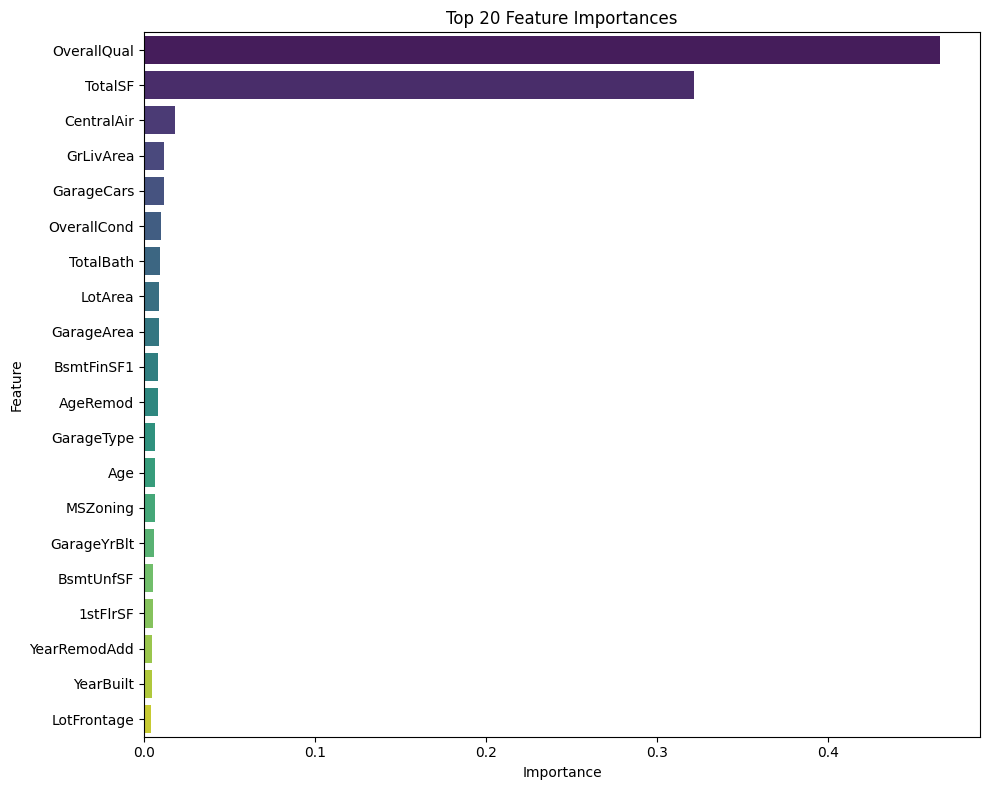

In [72]:
# 3. Feature Importance with Random Forest

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)   # ← This will now work without error

# Importance dataframe
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n=== Top 20 Most Important Features ===")
print(importance_df.head(20).to_string(index=False))

# Plot
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(20), palette='viridis')
plt.title('Top 20 Feature Importances')
plt.tight_layout()
plt.show()

=== Target Distribution Analysis ===
Mean   : 180932.92
Median : 163000.00
Skewness (original) : 1.881
Skewness (log1p)    : 0.122


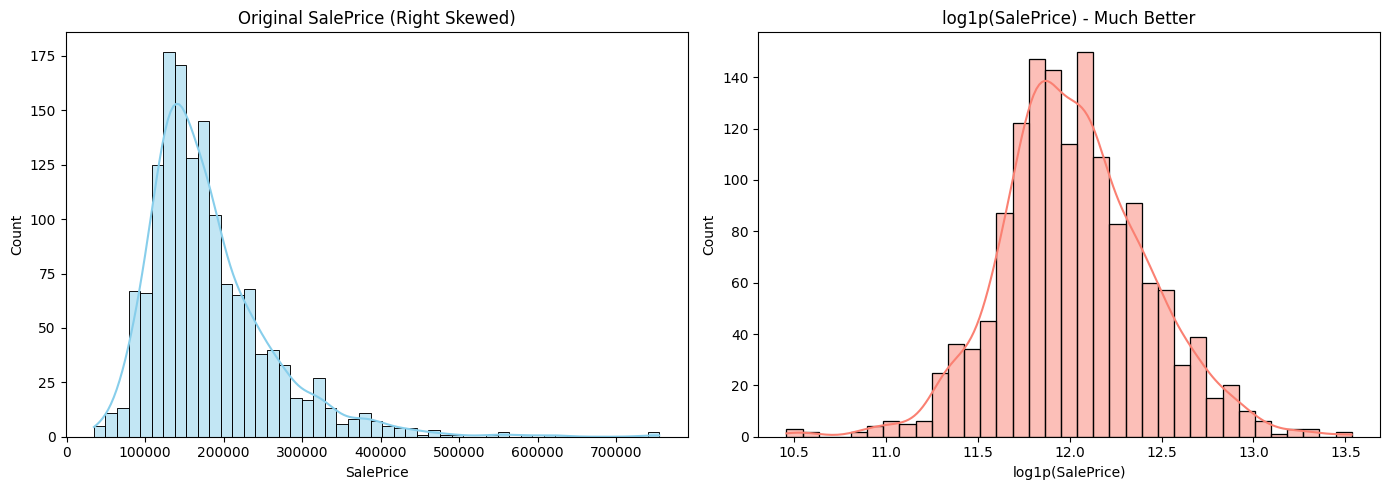

In [73]:
# Target Distribution Check (Regression version)

y = train_encoded['SalePrice']

print("=== Target Distribution Analysis ===")
print(f"Mean   : {y.mean():.2f}")
print(f"Median : {y.median():.2f}")
print(f"Skewness (original) : {y.skew():.3f}")
print(f"Skewness (log1p)    : {np.log1p(y).skew():.3f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(y, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title("Original SalePrice (Right Skewed)")
axes[0].set_xlabel("SalePrice")

sns.histplot(np.log1p(y), kde=True, ax=axes[1], color='salmon')
axes[1].set_title("log1p(SalePrice) - Much Better")
axes[1].set_xlabel("log1p(SalePrice)")

plt.tight_layout()
plt.show()

#  Step 8:- Model Building ( Supervised(ensemble))

In [74]:
# Model Building

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# ----------------------------------------------------------
# 0. Prepare Data (with encoding)
# ----------------------------------------------------------
train_model = train_encoded.copy()
test_model  = test_encoded.copy()

X = train_model.drop(columns=['Id', 'SalePrice'])
y = np.log1p(train_model['SalePrice'])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1458, 91)
y shape: (1458,)


In [75]:
# 5-Fold CV
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def rmsle_cv(model, X, y):
    scores = []
    for train_idx, valid_idx in kf.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[valid_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[valid_idx]
        
        model.fit(X_tr, y_tr)
        pred = model.predict(X_val)
        score = np.sqrt(mean_squared_error(y_val, pred))
        scores.append(score)
    return np.array(scores)

# RMSLE Score,Meaning,Quality
# 0.40,Baseline (just predict average),Bad
# 0.20,Decent model,Okay
# 0.15,Good model,Good
# 0.12,Strong model,Very Good
# 0.10,Excellent model,Excellent
# 0.00,Perfect predictions,Impossible

In [76]:

# 1. Baseline Model (Mean Prediction)
baseline_pred = np.full_like(y, y.mean())
baseline_score = np.sqrt(mean_squared_error(y, baseline_pred))
print(f"\nBaseline RMSLE (predict mean): {baseline_score:.5f}")

# 2. Ridge Regression
ridge = Ridge(alpha=10, random_state=42)
ridge_scores = rmsle_cv(ridge, X, y)
print(f"Ridge     CV RMSLE: {ridge_scores} ± {ridge_scores}")
print(f"Ridge     CV RMSLE: {ridge_scores.mean():.5f} ± {ridge_scores.std():.5f}")

# 3. Lasso Regression
lasso = Lasso(alpha=0.001, random_state=42, max_iter=5000)
lasso_scores = rmsle_cv(lasso, X, y)
print(f"Lasso     CV RMSLE: {lasso_scores.mean():.5f} ± {lasso_scores.std():.5f}")

# 4. Random Forest
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_scores = rmsle_cv(rf, X, y)
print(f"RandomForest CV RMSLE: {rf_scores.mean():.5f} ± {rf_scores.std():.5f}")


Baseline RMSLE (predict mean): 0.39958
Ridge     CV RMSLE: [0.12438256 0.11440787 0.13004271 0.12888484 0.10788743] ± [0.12438256 0.11440787 0.13004271 0.12888484 0.10788743]
Ridge     CV RMSLE: 0.12112 ± 0.00861
Lasso     CV RMSLE: 0.12143 ± 0.00944
RandomForest CV RMSLE: 0.13431 ± 0.00576


# Now Use Advanced Models (XGBoost + LightGBM)


In [77]:
# Run this only once

!pip install xgboost lightgbm -q

# ----------------------------------------------------------
# 5. XGBoost

    Parameter,  What it means,Effect of Increasing it,Typical Range
    
    n_estimators,       Number of trees,More trees → better fit (but slower),             500 – 2000
    learning_rate,      How fast the model learns,Smaller = more careful learning,       0.01 – 0.1
    max_depth,          How deep each tree can grow,Deeper = more complex,                  3 – 8
    subsample,          % of rows used for each tree,Lower = more regularization,         0.6 – 0.9
    colsample_bytree,   % of features used for each tree,Lower = more regularization,     0.6 – 0.9
    reg_alpha (L1),     L1 regularization,Higher = simpler model,                           0 – 1
    reg_lambda (L2),    L2 regularization,Higher = simpler model,                          0.5 – 2 

# ----------------------------------------------------------

In [78]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50
)

# Special CV for XGBoost (with early stopping)
xgb_scores = []
for fold, (train_idx, valid_idx) in enumerate(kf.split(X), 1):
    X_tr, X_val = X.iloc[train_idx], X.iloc[valid_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[valid_idx]
    
    xgb_model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    pred = xgb_model.predict(X_val)
    score = np.sqrt(mean_squared_error(y_val, pred))
    xgb_scores.append(score)
    print(f"XGB Fold {fold}: {score:.5f}")

print(f"XGBoost   CV RMSLE: {np.mean(xgb_scores):.5f} ± {np.std(xgb_scores):.5f}")

XGB Fold 1: 0.11836
XGB Fold 2: 0.11238
XGB Fold 3: 0.11859
XGB Fold 4: 0.12608
XGB Fold 5: 0.10963
XGBoost   CV RMSLE: 0.11701 ± 0.00570


# ----------------------------------------------------------
# 6. LightGBM

    Parameter,Meaning,Typical Value
    num_leaves,          Maximum number of leaves in one tree,     15 – 63
    max_depth,           Same as XGBoost,                        4 – 8 or -1
    min_child_samples,   Minimum data needed in a leaf,            10 – 50 

# ----------------------------------------------------------

In [79]:

from lightgbm import LGBMRegressor

lgb_model = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgb_scores = rmsle_cv(lgb_model, X, y)
print(f"LightGBM  CV RMSLE: {lgb_scores.mean():.5f} ± {lgb_scores.std():.5f}")

LightGBM  CV RMSLE: 0.12363 ± 0.00616


# Step 9:- Cross Validation 

In [80]:
# Cross-Validation

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# 1. Prepare Data
train_cv = train_encoded.copy()
test_cv  = test_encoded.copy()

X = train_cv.drop(columns=['Id', 'SalePrice'])
y = np.log1p(train_cv['SalePrice'])

print("X shape:", X.shape)

# 2. Create Cross-Validation Object
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def cv_rmsle(model, X, y, model_name="Model"):
    """Perform 5-Fold CV and return RMSLE scores"""
    scores = []
    oof_pred = np.zeros(len(y))
    
    for fold, (train_idx, valid_idx) in enumerate(kf.split(X), 1):
        X_tr, X_val = X.iloc[train_idx], X.iloc[valid_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[valid_idx]
        
        model.fit(X_tr, y_tr)
        pred = model.predict(X_val)
        
        score = np.sqrt(mean_squared_error(y_val, pred))
        scores.append(score)
        oof_pred[valid_idx] = pred
        
        print(f"{model_name} | Fold {fold} RMSLE: {score:.5f}")
    
    mean_score = np.mean(scores)
    std_score  = np.std(scores)
    print(f"→ {model_name} | Mean CV RMSLE: {mean_score:.5f} ± {std_score:.5f}\n")
    
    return mean_score, std_score, oof_pred

# 3. Evaluate Different Models

# 1. Ridge
ridge = Ridge(alpha=10, random_state=42)
ridge_mean, ridge_std, _ = cv_rmsle(ridge, X, y, "Ridge")

# 2. Random Forest
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_mean, rf_std, _ = cv_rmsle(rf, X, y, "RandomForest")

# 3. XGBoost
xgb = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50
)

# Special handling for early stopping
xgb_scores = []
for fold, (train_idx, valid_idx) in enumerate(kf.split(X), 1):
    X_tr, X_val = X.iloc[train_idx], X.iloc[valid_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[valid_idx]
    
    xgb.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    pred = xgb.predict(X_val)
    score = np.sqrt(mean_squared_error(y_val, pred))
    xgb_scores.append(score)
    print(f"XGBoost | Fold {fold} RMSLE: {score:.5f}")

print(f"→ XGBoost | Mean CV RMSLE: {np.mean(xgb_scores):.5f} ± {np.std(xgb_scores):.5f}\n")

# 4. LightGBM
lgb = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgb_mean, lgb_std, _ = cv_rmsle(lgb, X, y, "LightGBM")

X shape: (1458, 91)
Ridge | Fold 1 RMSLE: 0.12438
Ridge | Fold 2 RMSLE: 0.11441
Ridge | Fold 3 RMSLE: 0.13004
Ridge | Fold 4 RMSLE: 0.12888
Ridge | Fold 5 RMSLE: 0.10789
→ Ridge | Mean CV RMSLE: 0.12112 ± 0.00861

RandomForest | Fold 1 RMSLE: 0.14177
RandomForest | Fold 2 RMSLE: 0.12775
RandomForest | Fold 3 RMSLE: 0.13801
RandomForest | Fold 4 RMSLE: 0.13665
RandomForest | Fold 5 RMSLE: 0.12739
→ RandomForest | Mean CV RMSLE: 0.13431 ± 0.00576

XGBoost | Fold 1 RMSLE: 0.11836
XGBoost | Fold 2 RMSLE: 0.11238
XGBoost | Fold 3 RMSLE: 0.11859
XGBoost | Fold 4 RMSLE: 0.12608
XGBoost | Fold 5 RMSLE: 0.10963
→ XGBoost | Mean CV RMSLE: 0.11701 ± 0.00570

LightGBM | Fold 1 RMSLE: 0.13245
LightGBM | Fold 2 RMSLE: 0.11353
LightGBM | Fold 3 RMSLE: 0.13025
LightGBM | Fold 4 RMSLE: 0.13060
LightGBM | Fold 5 RMSLE: 0.11645
→ LightGBM | Mean CV RMSLE: 0.12466 ± 0.00798



# Step 10:- Hyperparameter Optimization !Take Time 5 - 10 Minutes

In [81]:
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import mean_squared_error, make_scorer

# 1. Prepare Data
train_tune = train_encoded.copy()
test_tune  = test_encoded.copy()

X = train_tune.drop(columns=['Id', 'SalePrice'])
y = np.log1p(train_tune['SalePrice'])

# Custom RMSLE scorer (lower is better)
def rmsle_score(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmsle_scorer = make_scorer(rmsle_score, greater_is_better=False)

kf = KFold(n_splits=5, shuffle=True, random_state=42)


In [82]:
# 2. Tune XGBoost
print("=== Tuning XGBoost ===")

xgb = XGBRegressor(random_state=42, n_jobs=-1)

xgb_param_dist = {
    'n_estimators': [800, 1000, 1200, 1500],
    'learning_rate': [0.01, 0.03, 0.05, 0.07],
    'max_depth': [3, 4, 5, 6],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [0.5, 1.0, 1.5]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_param_dist,
    n_iter=20,                    # Number of random combinations to try
    scoring=rmsle_scorer,
    cv=kf,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X, y)

print("\nBest XGBoost Parameters:")
print(xgb_search.best_params_)
print(f"Best XGBoost CV RMSLE: {-xgb_search.best_score_:.5f}")

best_xgb = xgb_search.best_estimator_

=== Tuning XGBoost ===
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best XGBoost Parameters:
{'subsample': 0.8, 'reg_lambda': 1.5, 'reg_alpha': 0, 'n_estimators': 1000, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.7}
Best XGBoost CV RMSLE: 0.11549


In [83]:
# # 3. Tune LightGBM
# print("\n=== Tuning LightGBM ===")

# lgb = LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)

# lgb_param_dist = {
#     'n_estimators': [800, 1000, 1200, 1500],
#     'learning_rate': [0.01, 0.03, 0.05, 0.07],
#     'num_leaves': [15, 31, 47, 63],
#     'max_depth': [4, 5, 6, 7, -1],
#     'subsample': [0.7, 0.8, 0.9],
#     'colsample_bytree': [0.7, 0.8, 0.9],
#     'reg_alpha': [0, 0.1, 0.5],
#     'reg_lambda': [0.5, 1.0, 1.5]
# }

# lgb_search = RandomizedSearchCV(
#     estimator=lgb,
#     param_distributions=lgb_param_dist,
#     n_iter=20,
#     scoring=rmsle_scorer,
#     cv=kf,
#     verbose=1,
#     random_state=42,
#     n_jobs=-1
# )

# lgb_search.fit(X, y)

# print("\nBest LightGBM Parameters:")
# print(lgb_search.best_params_)
# print(f"Best LightGBM CV RMSLE: {-lgb_search.best_score_:.5f}")

# best_lgb = lgb_search.best_estimator_

# Step 11:- Model Evaluation ( Regression) - Takes Time

In [84]:
# 1. Prepare Data (same as before)
train_eval = train_encoded.copy()
test_eval  = test_encoded.copy()

X = train_eval.drop(columns=['Id', 'SalePrice'])
y = np.log1p(train_eval['SalePrice'])
y_original = train_eval['SalePrice']   # original scale for analysis 

kf = KFold(n_splits=5, shuffle=True, random_state=42)
kf

KFold(n_splits=5, random_state=42, shuffle=True)

In [85]:
# 2. Generate Out-of-Fold Predictions (using best models)
# We use the best models from STEP 11
# If you haven't run tuning, you can use the models defined earlier

def get_oof_predictions(model, X, y):
    oof = np.zeros(len(X))
    
    for train_idx, valid_idx in kf.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[valid_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[valid_idx]
        
        model.fit(X_tr, y_tr)
        oof[valid_idx] = model.predict(X_val)
    
    return oof

print("Generating Out-of-Fold predictions...")

# Using the best models from previous step
# Replace with best_xgb and best_lgb if you ran the tuning
oof_xgb = get_oof_predictions(best_xgb, X, y)
# oof_lgb = get_oof_predictions(best_lgb, X, y)

# Simple average blend
# oof_blend = 0.5 * oof_xgb + 0.5 * oof_lgb

Generating Out-of-Fold predictions...


In [86]:
# 3. Calculate Final Scores
def rmsle(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

print("\n=== Final CV Results (RMSLE) ===")
print(f"XGBoost  : {rmsle(y, oof_xgb):.5f}")
# print(f"LightGBM : {rmsle(y, oof_lgb):.5f}")
# print(f"Blend    : {rmsle(y, oof_blend):.5f}")


=== Final CV Results (RMSLE) ===
XGBoost  : 0.11562


In [87]:
# 4. Residual Analysis
# Convert predictions back to original scale for easier understanding

# pred_original = np.expm1(oof_blend)
# residuals = y_original - pred_original

# print("\n=== Residual Statistics ===")
# print(residuals.describe())

# # Residual Distribution
# plt.figure(figsize=(12, 5))

# plt.subplot(1, 2, 1)
# sns.histplot(residuals, kde=True, color='steelblue')
# plt.title("Residual Distribution")
# plt.xlabel("Residual (Actual - Predicted)")

# plt.subplot(1, 2, 2)
# sns.scatterplot(x=pred_original, y=residuals, alpha=0.5)
# plt.axhline(0, color='red', linestyle='--')
# plt.title("Residuals vs Predicted Price")
# plt.xlabel("Predicted SalePrice")
# plt.ylabel("Residual")

# plt.tight_layout()
# plt.show()

In [88]:
# 5. Actual vs Predicted
# plt.figure(figsize=(8, 6))
# sns.scatterplot(x=y_original, y=pred_original, alpha=0.5)
# plt.plot([y_original.min(), y_original.max()], 
#          [y_original.min(), y_original.max()], 
#          color='red', linestyle='--', label='Perfect Prediction')
# plt.xlabel("Actual SalePrice")
# plt.ylabel("Predicted SalePrice")
# plt.title("Actual vs Predicted SalePrice")
# plt.legend()
# plt.show()

In [89]:
# 6. Error Analysis - Best & Worst Predictions
# error_df = pd.DataFrame({
#     'Id': train_eval['Id'],
#     'Actual': y_original,
#     'Predicted': pred_original,
#     'Residual': residuals,
#     'Abs_Error': np.abs(residuals)
# })

# print("\n=== Top 5 Worst Predictions (Highest Absolute Error) ===")
# display(error_df.sort_values('Abs_Error', ascending=False).head(5))

# print("\n=== Top 5 Best Predictions (Lowest Absolute Error) ===")
# display(error_df.sort_values('Abs_Error').head(5))

# Step 12:- Final Model and Submission

In [90]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import warnings
warnings.filterwarnings('ignore')

# ----------------------------------------------------------
# 1. Prepare Full Data
# ----------------------------------------------------------
train_final = train_eval.copy()
test_final  = test_eval.copy()

X_full = train_final.drop(columns=['Id', 'SalePrice'])
y_full = np.log1p(train_final['SalePrice'])

X_test = test_final.drop(columns=['Id'])

print("X_full shape:", X_full.shape)
print("X_test shape:", X_test.shape)

X_full shape: (1458, 91)
X_test shape: (1459, 91)


# ----------------------------------------------------------
# 2. Retrain Models with Best Parameters on Full Training Data

    Best XGBoost Parameters:
    {'subsample': 0.8, 'reg_lambda': 1.5, 'reg_alpha': 0, 'n_estimators': 1000, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.7}
    Best XGBoost CV RMSLE: 0.11422, 
    
    Best LightGBM Parameters:
    {'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alpha': 0.1, 'num_leaves': 15, 'n_estimators': 1500, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
    
    Best LightGBM CV RMSLE: 0.12013, 
    XGBoost  : 0.11436
    LightGBM : 0.12035
    Blend    : 0.11602
# ----------------------------------------------------------

# ----- XGBoost -----

In [91]:

final_xgb = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.7,
    reg_alpha=0,
    reg_lambda=1.5,
    random_state=42,
    n_jobs=-1
)

final_xgb.fit(X_full, y_full)
pred_xgb = final_xgb.predict(X_test)


# ----- LightGBM -----
final_lgb = LGBMRegressor(
    n_estimators=1500,
    learning_rate=0.01,
    num_leaves=15,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.7,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

final_lgb.fit(X_full, y_full)
pred_lgb = final_lgb.predict(X_test)


In [92]:
# 3. Create Blend Prediction
# Simple average blend (usually works very well)
final_pred_log = 0.50 * pred_xgb + 0.50 * pred_lgb

# Convert back to original price scale
final_pred = np.expm1(final_pred_log)

print("\nPrediction statistics:")
print(pd.Series(final_pred).describe())

# 4. Create Submission File
submission = pd.DataFrame({
    'Id': test_final['Id'],
    'SalePrice': final_pred
})

# Basic checks
print("\n=== Submission Checks ===")
print("Shape:", submission.shape)
print("Any missing values?", submission.isnull().sum().sum())
print("\nFirst 5 rows:")
print(submission.head())

# Save the file
submission.to_csv('submission.csv', index=False)
print("\nSubmission file saved successfully as 'submission.csv'")


Prediction statistics:
count      1459.000000
mean     178524.516091
std       79453.761622
min       46207.614966
25%      128038.538484
50%      156688.729067
75%      208678.938145
max      643597.082843
dtype: float64

=== Submission Checks ===
Shape: (1459, 2)
Any missing values? 0

First 5 rows:
        Id      SalePrice
1458  1461  121475.247040
1459  1462  163589.637970
1460  1463  181255.250703
1461  1464  198111.930696
1462  1465  188472.226263

Submission file saved successfully as 'submission.csv'
